# Final model — training, one-time internal test and saved models (single notebook)

This notebook trains the project's **final PD detection model** from start to finish and **saves it** for use outside Kaggle. It needs **only the Data preparation v4 output**: B0, the CNN, the calibration and the blend are all trained here, so no Test 5, 6 or 7 outputs are attached.

**Final model (chosen in Test 7):** calibrated blend of
- **CNN** (`CNN6b_3_aug`, weight 0.25): SharedPhaseCNN with B0's features as side input and strong augmentation, 10 repeats × 5 folds = 50 networks;
- **B0** (weight 0.75): LightGBM on the 9 peak features of the competition's 1st-place solution (Kaggle user mark4h, re-implemented in Test 5), 25 repeats × 5 folds = 125 models.

**Stages:**

| Stage | Training data | Purpose |
|---|---|---|
| **A — reproduce and test** | Pool only (training + validation, 2,468 measurements), exactly as in Tests 5–7 | (1) Check that this single notebook reproduces Test 7 (CV MCC: B0 0.726, CNN 0.704, blend 0.729). (2) **One-time evaluation on the internal test set** (1,308 signals, untouched since Test 1): the project's only unbiased performance estimate, with bootstrap 95% confidence intervals and paired comparisons between the models |
| **B — final models** | **All labelled data** (2,904 measurements) | Same recipe and same blend weight (0.25); calibration and cut-off re-fitted on the all-data CV predictions. These models are **saved** and used for one final Kaggle file |
| **C — performance evaluation for the report** | — | All metrics at signal and measurement level (MCC, F1, recall, precision, specificity, NPV, balanced accuracy, ROC AUC, PR AUC, Brier score, confusion counts), CV stability across repeats, CNN learning curves, B0 feature importance, model size, training and inference time. Report figures (PNG), tables (CSV), `metrics_summary.json` and `evaluation_summary.md` are written to `report/` and zipped as `report_outputs.zip` |

**Saved to `final_model/` (also zipped as `final_model.zip`):**

| File | Contents |
|---|---|
| `pd_inference.py` | Self-contained Python module: peak extraction (identical to Data prep v4), features, model definition and a `PDDetector` class that predicts from raw signals |
| `cnn_ensemble.pt` | The 50 CNN weight sets, each with its own normalisation statistics |
| `b0_ensemble.json.gz` | The 125 LightGBM models (text format, compressed) |
| `config.json` | Blend weight, cut-off, calibration, peak and grid settings, training summary, library versions |
| `README.md` | How to use the model on a local computer |

A check section loads the saved files with `pd_inference.py`, exactly as a local app would, and checks that they give the same predictions as the models in memory. If the **competition data** is also attached, it also runs the full raw-signal path (raw → peaks → features → prediction) on a few recordings, checks it against the Data prep v4 peak table and times it.

**Files to download after the run:** `final_model.zip` (the model, for the local app) and `report_outputs.zip` (figures, tables and the summary for the report). `submission_final_model_all_data.csv` is the optional single Kaggle submission.

**Inputs to attach:** the committed output of **Data preparation v4** (required) and the **competition data** (optional, for the raw-signal check). Switch on the **GPU**. Run once with `QUICK_TEST = True` (a few minutes; the internal test is skipped and the saved models are only for testing), then set it to `False` and commit with **Save & Run All** (roughly 30–60 minutes on GPU: 100 CNNs and 250 LightGBM models are trained).

## 1. Settings

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import glob, gzip, json, random, shutil, sys, time, warnings, importlib
warnings.filterwarnings('ignore', message='.*eval_set.*')
import numpy as np
import pandas as pd
import scipy
import torch
import torch.nn as nn
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (matthews_corrcoef, roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

QUICK_TEST = False          # True = 1 repeat and 3 epochs, internal test skipped: only to check the notebook runs

N_FOLDS, SEED_BASE = 5, 1000                                  # same fold seeds as Tests 5-8
N_REPEATS_CNN = 1 if QUICK_TEST else 10                        # 50 CNNs
N_REPEATS_B0 = 1 if QUICK_TEST else 25                         # 125 LightGBM models
BATCH_SIZE, MAX_EPOCHS, PATIENCE, LR, WEIGHT_DECAY = 64, (3 if QUICK_TEST else 150), 20, 1e-3, 1e-3
MAX_SHIFT, PHASE_SHIFT, HEIGHT_JITTER, BIN_DROP = 2, 1, 0.25, 0.05   # CNN augmentation (Test 7, variant 3)
LGB_PARAMS = dict(objective='binary', learning_rate=0.01, num_leaves=80, colsample_bytree=0.8,
                  subsample=0.8, subsample_freq=1, n_estimators=10000, verbose=-1)   # winner's settings (Test 5)
EARLY_STOP = 100
W_FINAL = 0.25              # CNN weight of the final blend (chosen in Test 7)
THRESHOLDS = np.r_[np.arange(0.01, 0.99, 0.01), np.arange(0.99, 0.9995, 0.001)].round(3)
EXPECTED_TEST7 = {'B0': (0.726, 741), 'CNN': (0.704, 711), 'Blend': (0.729, 684)}   # CV MCC, Kaggle PD signals

N_BOOT = 2000              # bootstrap resamples for the confidence intervals

INPUT_DIR, OUT_DIR = '/kaggle/input', '/kaggle/working'
MODEL_DIR = f'{OUT_DIR}/final_model'
REPORT_DIR = f'{OUT_DIR}/report'                              # figures, tables and summary for the report
FIG_DIR = f'{REPORT_DIR}/figures'
for d in (MODEL_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print('Using device:', DEVICE_NAME, '| PyTorch', torch.__version__, '| LightGBM', lgb.__version__, '| QUICK_TEST' if QUICK_TEST else '')
T_START = time.time()
TIMES = {}                 # training times, for the report

# Figure style (same colours in every figure: final model blue, B0 orange, CNN aqua)
COL = {'Final model (blend)': '#2a78d6', 'B0': '#eb6834', 'CNN': '#1baf7a'}
GREY, INK, INK2 = '#8a8985', '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.size': 10, 'axes.titlesize': 11,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': GREY,
                     'axes.labelcolor': INK, 'xtick.color': INK2, 'ytick.color': INK2, 'text.color': INK,
                     'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8, 'legend.frameon': False,
                     'lines.linewidth': 1.8, 'figure.facecolor': 'white', 'savefig.facecolor': 'white',
                     'savefig.bbox': 'tight'})

Using device: Tesla T4 | PyTorch 2.11.0+cu128 | LightGBM 4.6.0 


## 2. The inference module

Everything needed to turn raw signals into a prediction is written to `final_model/pd_inference.py`, and **this notebook uses the same module** for its features. The training and the saved model can therefore never drift apart. The peak extraction is copied from Data preparation v4 and was checked to give identical peak tables.

In [2]:
%%writefile /kaggle/working/final_model/pd_inference.py
"""pd_inference.py — partial discharge (PD) detector: the project's final model (Test 7 blend).

Self-contained: peak extraction, features, model definition and the saved ensembles.

    from pd_inference import PDDetector
    det = PDDetector('final_model')            # folder with config.json, cnn_ensemble.pt, b0_ensemble.json.gz
    result = det.predict_raw(raw)               # raw: array of shape (3, 800000), the three phases of one recording
    print(result['pd'], result['probability'])

Input format: VSB / ENET format, one 20 ms recording (one 50 Hz cycle) of all three phases, 800,000 samples per
phase at 40 MHz, raw ADC values. Other formats need resampling and checking before the model's output can be trusted.

Model: calibrated blend of
  * CNN  (weight 0.25): SharedPhaseCNN ensemble on phase-resolved peak grids (this project, Test 7 variant 3);
  * B0   (weight 0.75): LightGBM ensemble on 9 peak features, a re-implementation of the 1st-place solution of the
         Kaggle VSB Power Line Fault Detection competition (Kaggle user mark4h).
"""
import gzip
import json
import os

import lightgbm as lgb
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import signal as sps
from scipy.ndimage import maximum_filter1d

# ---------------------------------------------------------------- settings (identical to Data preparation v4 and Tests 5-7)
N_SAMPLES = 800_000
N_BINS = 64                                    # 5.625 degrees per bin
WINDOW = 25                                    # local maxima: largest within +-25 samples
KNEE_GRAD, KNEE_COUNT, CONV_LENGTH = -0.01, 1000, 9
SMALL_W, LARGE_W = 5, 25
TEMPLATE_LENGTHS = (2, 3, 5)
COUNT_CH = ['count', 'count_pos', 'count_neg', 'sum_rel_height']
MEAN_CH = ['sawtooth_2', 'sawtooth_3', 'ratio_next', 'ratio_prev', 'abs_dist', 'width']
CHANNELS = COUNT_CH + MEAN_CH
N_CH = len(CHANNELS)
B0_COLS = ['peak_count_Q13', 'abs_small_dist_to_min_mean_Q02', 'height_mean_Q02', 'height_std_Q02',
           'sawtooth_rmse_mean_Q02', 'peak_count_Q02', 'ratio_next_mean_Q02', 'ratio_prev_mean_Q02', 'peak_count_total']

# ---------------------------------------------------------------- peak extraction (Data preparation v4; winner's method)
_TRIG = {}


def phase_offset(raw):
    """Phase of the 50 Hz component from the first Fourier coefficient: raw ~ A*cos(2*pi*n/N + phi)."""
    n_s = len(raw)
    if n_s not in _TRIG:
        n = np.arange(n_s)
        _TRIG[n_s] = (np.cos(2 * np.pi * n / n_s).astype(np.float32), np.sin(2 * np.pi * n / n_s).astype(np.float32))
    cos, sin = _TRIG[n_s]
    x = raw.astype(np.float32)
    a, b = float(x @ cos), float(x @ sin)
    phi = np.arctan2(-b, a)
    shift = int(round(((-(phi + np.pi / 2)) % (2 * np.pi)) / (2 * np.pi) * n_s)) % n_s
    return phi, 2 * np.hypot(a, b) / n_s, shift


def flatiron(x, alpha=100., beta=1.):
    a, b = (alpha - beta) / alpha, beta / alpha
    zero, _ = sps.lfilter([b], [1, -a], x[1:], zi=[a * x[0]])
    out = np.empty_like(x)
    out[0] = 0.0
    out[1:] = x[1:] - zero
    return out


def local_maxima(xa, w=WINDOW):
    m = maximum_filter1d(xa, size=2 * w + 1, mode='nearest')
    i = np.where(xa == m)[0]
    i = i[(i > 0) & (i < len(xa) - 1)]
    return i[xa[i] > xa[i - 1]]


def knee_filter(px, heights, xh):
    order = np.argsort(heights)[::-1]
    px, heights = px[order], heights[order]
    grad = np.convolve(np.diff(heights), np.ones(CONV_LENGTH) / CONV_LENGTH)[CONV_LENGTH - 1:-CONV_LENGTH + 1]
    reached = np.where(np.cumsum(grad > KNEE_GRAD) >= KNEE_COUNT)[0]
    knee = (reached[0] - KNEE_COUNT - CONV_LENGTH // 2) if len(reached) else -1
    fallback = knee <= 0
    if fallback:
        sigma = np.median(np.abs(xh - np.median(xh))) / 0.6745 + 1e-9
        keep = heights > 5 * sigma
        px, heights, knee_height = px[keep], heights[keep], 5 * sigma
    else:
        knee_height = heights[knee]
        px, heights = px[:knee], heights[:knee]
    order = np.argsort(px)
    return px[order], heights[order], float(knee_height), bool(fallback)


_off_s, _off_l = np.arange(-SMALL_W, SMALL_W + 1), np.arange(-LARGE_W, LARGE_W + 1)
TEMPLATES = {}
for _L in TEMPLATE_LENGTHS:
    _t = np.zeros(2 * LARGE_W + 1)
    for _i in range(_L + 1):
        _t[LARGE_W + _i] = 1 - (2.0 / _L) * _i
    TEMPLATES[_L] = _t


def peak_table(raw, phi):
    """Peaks of one phase above its noise-floor knee, with the per-peak features of the winner's method."""
    xh = flatiron(raw.astype(np.float64))
    xa = np.abs(xh)
    px_all = local_maxima(xa)
    px, _, knee_height, fallback = knee_filter(px_all, xa[px_all], xh)
    nn_ = len(xh)
    h0 = xh[px]
    s = np.where(h0 >= 0, 1.0, -1.0)
    a0 = np.abs(h0)
    win_s = xh[np.clip(px[:, None] + _off_s, 0, nn_ - 1)]
    win_l = xh[np.clip(px[:, None] + _off_l, 0, nn_ - 1)] * s[:, None] / a0[:, None]
    feats = {'px': px, 'height': a0, 'sign': s,
             'ratio_next': np.abs(xh[np.minimum(px + 1, nn_ - 1)]) / a0,
             'ratio_prev': np.abs(xh[np.maximum(px - 1, 0)]) / a0,
             'small_dist_to_min': np.argmin(win_s * s[:, None], axis=1) - SMALL_W,
             'width': (np.abs(win_s) >= 0.5 * a0[:, None]).sum(axis=1)}
    for L, t in TEMPLATES.items():
        feats[f'sawtooth_{L}'] = ((win_l - t) ** 2).mean(axis=1)
    feats['phase_deg'] = (np.degrees(2 * np.pi * px / N_SAMPLES + phi) + 90) % 360
    return feats, knee_height, fallback


def _cast(df):                                   # same column types as the saved Data prep v4 peak table
    for c in ['height', 'ratio_next', 'ratio_prev', 'phase_deg'] + [f'sawtooth_{L}' for L in TEMPLATE_LENGTHS]:
        df[c] = df[c].astype(np.float32)
    for c, t in [('px', np.int32), ('sign', np.int8), ('small_dist_to_min', np.int8), ('width', np.int8)]:
        df[c] = df[c].astype(t)
    return df


def peaks_from_raw(raw3, id_measurement=0):
    """Peak table of one recording: raw3 has shape (3, 800000), phases in order 0, 1, 2."""
    raw3 = np.asarray(raw3)
    assert raw3.shape == (3, N_SAMPLES), f'expected shape (3, {N_SAMPLES}), got {raw3.shape}'
    frames, info = [], []
    for ph in range(3):
        phi, amp, _ = phase_offset(raw3[ph])
        feats, knee, fallback = peak_table(raw3[ph], phi)
        df = _cast(pd.DataFrame(feats))
        df['phase'], df['knee_height'], df['id_measurement'] = ph, knee, id_measurement
        frames.append(df)
        info.append({'phase': ph, 'knee_height': knee, 'fallback': fallback, 'peaks_kept': len(df), 'amp50': amp})
    return pd.concat(frames, ignore_index=True), info


# ---------------------------------------------------------------- features (Tests 5-7)
def prepare_peaks(p):
    """Winner's interference filter, then the columns used by the grids. p needs id_measurement, phase, knee_height."""
    p = p[~((p['ratio_next'] > 1 / 3) & (p['height'] > 50))].copy()
    p['rel_height'] = p['height'] / p['knee_height'].clip(lower=1e-6)
    p['abs_dist'] = p['small_dist_to_min'].abs().astype(np.float32)
    p['bin'] = (p['phase_deg'] / (360 / N_BINS)).astype(int).clip(0, N_BINS - 1)
    return p


def build_grid(p, ids, fill):
    """Phase-resolved peak grids, shape (len(ids), 3 * 10, 64). fill: mean of each shape channel over training peaks."""
    row = pd.Series(np.arange(len(ids)), index=ids)
    r, ph, b = row.loc[p['id_measurement']].values, p['phase'].values, p['bin'].values
    G = np.zeros((len(ids), 3, N_CH, N_BINS), dtype=np.float32)
    np.add.at(G, (r, ph, 0, b), np.ones(len(p), dtype=np.float32))
    np.add.at(G, (r, ph, 1, b), (p['sign'].values > 0).astype(np.float32))
    np.add.at(G, (r, ph, 2, b), (p['sign'].values < 0).astype(np.float32))
    np.add.at(G, (r, ph, 3, b), p['rel_height'].values.astype(np.float32))
    counts = G[:, :, 0, :].copy()
    for j, c in enumerate(MEAN_CH, start=len(COUNT_CH)):
        np.add.at(G, (r, ph, j, b), p[c].values.astype(np.float32))
        G[:, :, j, :] = np.where(counts > 0, G[:, :, j, :] / np.maximum(counts, 1), fill[c])
    G[:, :, :len(COUNT_CH), :] = np.log1p(G[:, :, :len(COUNT_CH), :])
    return G.reshape(len(ids), 3 * N_CH, N_BINS)


def b0_features(p, ids):
    """The 9 measurement-level features of the winner's method (peaks already filtered)."""
    p = p.assign(Q=(p['phase_deg'] // 90).astype(int).clip(0, 3))
    f = pd.DataFrame(index=pd.Index(ids, name='id_measurement'))
    g = p[p['Q'].isin([0, 2])].groupby('id_measurement')
    f['peak_count_Q02'] = g.size()
    f['peak_count_Q13'] = p[p['Q'].isin([1, 3])].groupby('id_measurement').size()
    f['peak_count_total'] = p.groupby('id_measurement').size()
    f['height_mean_Q02'] = g['height'].mean()
    f['height_std_Q02'] = g['height'].std()
    f['ratio_prev_mean_Q02'] = g['ratio_prev'].mean()
    f['ratio_next_mean_Q02'] = g['ratio_next'].mean()
    f['abs_small_dist_to_min_mean_Q02'] = g['abs_dist'].mean()
    f['sawtooth_rmse_mean_Q02'] = g['sawtooth_3'].mean()
    return f[B0_COLS]


def side_input(F):
    """CNN side input from B0's features: counts and heights log-scaled, plus a 'no Q0/Q2 peaks' indicator."""
    S = F.copy()
    for c in ['peak_count_Q02', 'peak_count_Q13', 'peak_count_total']:
        S[c] = np.log1p(F[c].fillna(0))
    for c in ['height_mean_Q02', 'height_std_Q02']:
        S[c] = np.log1p(F[c])
    S['no_Q02_peaks'] = (F['peak_count_Q02'].fillna(0) == 0).astype(float)
    return S.values.astype(np.float64)


# ---------------------------------------------------------------- CNN (Test 7, variant 3)
def conv_block(ci, co, k, pool):
    layers = [nn.Conv1d(ci, co, k, padding=k // 2, padding_mode='circular'), nn.BatchNorm1d(co), nn.ReLU()]
    return nn.Sequential(*layers, nn.MaxPool1d(2)) if pool else nn.Sequential(*layers)


class SharedPhaseCNN(nn.Module):
    def __init__(self, n_side=0):
        super().__init__()
        self.encoder = nn.Sequential(conv_block(N_CH, 32, 5, False), conv_block(32, 32, 5, True), conv_block(32, 64, 3, True))
        self.mix = nn.Sequential(nn.Conv1d(128, 32, 1), nn.BatchNorm1d(32), nn.ReLU())
        self.flat = nn.Sequential(nn.Flatten(), nn.Dropout(0.5))
        self.side = nn.Sequential(nn.Linear(n_side, 16), nn.ReLU()) if n_side else None
        self.head = nn.Sequential(nn.Linear(32 * (N_BINS // 4) + (16 if n_side else 0), 32), nn.ReLU(),
                                  nn.Dropout(0.5), nn.Linear(32, 1))

    def forward(self, x, side=None):
        b = len(x)
        h = self.encoder(x.reshape(b * 3, N_CH, N_BINS)).reshape(b, 3, 64, N_BINS // 4)
        h = self.flat(self.mix(torch.cat([h.mean(dim=1), h.amax(dim=1)], dim=1)))
        if self.side is not None:
            h = torch.cat([h, self.side(side)], dim=1)
        return self.head(h).squeeze(1)


def logit(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))


def calibrate(p, cal):
    return 1 / (1 + np.exp(-(cal['coef'] * logit(p) + cal['intercept'])))


# ---------------------------------------------------------------- detector
class PDDetector:
    def __init__(self, folder, device='cpu'):
        self.folder, self.device = folder, torch.device(device)
        with open(os.path.join(folder, 'config.json')) as f:
            self.cfg = json.load(f)
        self.fill = pd.Series(self.cfg['fill'])
        saved = torch.load(os.path.join(folder, 'cnn_ensemble.pt'), map_location=self.device, weights_only=True)
        self.cnn = []
        for m in saved['models']:
            net = SharedPhaseCNN(saved['n_side']).to(self.device)
            net.load_state_dict(m['state_dict'])
            net.eval()
            self.cnn.append(dict(net=net, mean=m['mean'].cpu().numpy().reshape(1, -1, 1),
                                 std=m['std'].cpu().numpy().reshape(1, -1, 1),
                                 mu=m['side_mu'].cpu().numpy(), sd=m['side_sd'].cpu().numpy()))
        with gzip.open(os.path.join(folder, 'b0_ensemble.json.gz'), 'rt') as f:
            self.b0 = [lgb.Booster(model_str=s) for s in json.load(f)['models']]

    def _cnn_prob(self, G, S):
        out = np.zeros(len(G))
        for m in self.cnn:
            x = ((G - m['mean']) / m['std']).astype(np.float32)
            s = ((np.where(np.isnan(S), m['mu'], S) - m['mu']) / m['sd']).astype(np.float32)
            with torch.no_grad():
                for i in range(0, len(x), 512):
                    p = torch.sigmoid(m['net'](torch.tensor(x[i:i + 512], device=self.device),
                                               torch.tensor(s[i:i + 512], device=self.device)))
                    out[i:i + 512] += p.cpu().numpy() / len(self.cnn)
        return out

    def _b0_prob(self, F):
        return np.mean([b.predict(F) for b in self.b0], axis=0)

    def predict_features(self, G, F):
        """G: grids (n, 30, 64); F: B0 features (n, 9) in B0_COLS order (NaN allowed)."""
        F = np.asarray(F, dtype=np.float64)
        S = side_input(pd.DataFrame(F, columns=B0_COLS))
        p_cnn, p_b0 = self._cnn_prob(np.asarray(G, dtype=np.float32), S), self._b0_prob(F)
        w = self.cfg['blend_weight']
        prob = w * calibrate(p_cnn, self.cfg['calibration']['cnn']) + (1 - w) * calibrate(p_b0, self.cfg['calibration']['b0'])
        return dict(cnn=p_cnn, b0=p_b0, probability=prob, pd=prob > self.cfg['cutoff'])

    def features_from_peaks(self, peaks, ids):
        p = prepare_peaks(peaks)
        return build_grid(p, ids, self.fill), b0_features(p, ids).values

    def predict_raw(self, raw3):
        """Predict one recording from its raw three-phase signal (shape (3, 800000))."""
        peaks, info = peaks_from_raw(raw3)
        G, F = self.features_from_peaks(peaks, np.array([0]))
        r = self.predict_features(G, F)
        counts = np.expm1(G[0].reshape(3, N_CH, N_BINS)[:, 0, :])        # cleaned peaks per phase and bin
        return dict(pd=bool(r['pd'][0]), probability=float(r['probability'][0]), cnn_probability=float(r['cnn'][0]),
                    b0_probability=float(r['b0'][0]), cutoff=self.cfg['cutoff'], phase_info=info,
                    peaks=peaks, peak_counts_per_bin=counts, bin_angles=(np.arange(N_BINS) + 0.5) * 360 / N_BINS)

Writing /kaggle/working/final_model/pd_inference.py


In [3]:
sys.dont_write_bytecode = True        # keep __pycache__ out of final_model/
sys.path.insert(0, MODEL_DIR)
import pd_inference as pdi
importlib.reload(pdi)
print('pd_inference loaded:', len(pdi.CHANNELS), 'grid channels,', len(pdi.B0_COLS), 'B0 features')

pd_inference loaded: 10 grid channels, 9 B0 features


## 3. Load Data preparation v4 and build the inputs

Peak tables → winner's interference filter → phase-resolved grids (3 phases × 10 channels × 64 bins) for the CNN and the 9 B0 features, exactly as in Tests 5–7.

In [4]:
def find(name, required=True):
    m = sorted(glob.glob(f'{INPUT_DIR}/**/{name}', recursive=True))
    assert m or not required, f'{name} not found: attach the committed Data preparation v4 output'
    return m[0] if m else None

D = find('peaks_train.parquet').rsplit('/', 1)[0]
meta = pd.read_csv(f'{D}/meta_train.csv')
meta_k = pd.read_csv(f'{D}/meta_kaggle_test.csv')
assert len(meta) == 8712 and len(meta_k) == 20337, 'quick-test output attached: commit Data prep v4 with LIMIT = None'

def load(name, m):
    p = pd.read_parquet(f'{D}/peaks_{name}.parquet')
    s = pd.read_csv(f'{D}/signals_{name}.csv')[['signal_id', 'knee_height']]
    p = p.merge(m[['signal_id', 'id_measurement', 'phase']], on='signal_id').merge(s, on='signal_id')
    return pdi.prepare_peaks(p)

peaks, peaks_k = load('train', meta), load('kaggle_test', meta_k)
FILL = peaks[pdi.MEAN_CH].astype(float).mean()

ids_all = np.sort(meta['id_measurement'].unique())
ids_k = np.sort(meta_k['id_measurement'].unique())
G, G_k = pdi.build_grid(peaks, ids_all, FILL), pdi.build_grid(peaks_k, ids_k, FILL)
F_df, F_k_df = pdi.b0_features(peaks, ids_all), pdi.b0_features(peaks_k, ids_k)
F_all, F_kag = F_df.values.astype(np.float64), F_k_df.values.astype(np.float64)
SIDE, SIDE_K = pdi.side_input(F_df), pdi.side_input(F_k_df)
N_SIDE = SIDE.shape[1]

y_meas = meta.groupby('id_measurement')['target'].max().loc[ids_all].values
split = meta.groupby('id_measurement')['split'].first().loc[ids_all].values
pool = np.where(np.isin(split, ['train', 'val']))[0]
test_rows = np.where(split == 'test')[0]
all_rows = np.arange(len(ids_all))
print(f'Grids {G.shape}, Kaggle {G_k.shape} | pool {len(pool)} measurements ({y_meas[pool].sum()} PD) | '
      f'internal test {len(test_rows)} ({y_meas[test_rows].sum()} PD) | all labelled {len(all_rows)} ({y_meas.sum()} PD)')

Grids (2904, 30, 64), Kaggle (6779, 30, 64) | pool 2468 measurements (165 PD) | internal test 436 (29 PD) | all labelled 2904 (194 PD)


## 4. Training and scoring functions

Identical to Tests 5–7: repeated stratified 5-fold CV on measurements; in each fold, fold *k* gives the out-of-fold (OOF) predictions, fold *k*+1 is used only for early stopping, and the other three train the model. B0 uses the winner's LightGBM settings; the CNN uses class-weighted BCE, Adam, early stopping on the stopping fold's loss and the variant-3 augmentation. Predictions for other sets (internal test, Kaggle test) are averaged over all fold models. Scoring is at signal level (each measurement's prediction given to its three signals), with the cut-off chosen on the OOF predictions and ties resolved to the middle.

In [5]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def fold_ids(y, seed):
    fold = np.zeros(len(y), dtype=int)
    for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=seed).split(np.zeros(len(y)), y)):
        fold[va] = k
    return fold

# ---------------- B0 (LightGBM)
def run_b0_cv(rows, evals, keep=False, label='B0'):
    X, y = F_all[rows], y_meas[rows]
    n_models, t0 = N_REPEATS_B0 * N_FOLDS, time.time()
    out = dict(oof=np.zeros((N_REPEATS_B0, len(rows))), evals={k: np.zeros(len(v)) for k, v in evals.items()}, models=[], iters=[])
    for r in range(N_REPEATS_B0):
        fold = fold_ids(y, SEED_BASE + r)
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            tr = ~(va | st)
            m = lgb.LGBMClassifier(**LGB_PARAMS, random_state=SEED_BASE + r)
            m.fit(X[tr], y[tr], eval_set=[(X[st], y[st])], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
            out['oof'][r, va] = m.predict_proba(X[va])[:, 1]
            for name, Xe in evals.items():
                out['evals'][name] += m.predict_proba(Xe)[:, 1] / n_models
            out['iters'].append(int(m.best_iteration_))
            if keep:
                out['models'].append(m.booster_.model_to_string(num_iteration=m.best_iteration_))
    print(f'{label}: {n_models} models in {(time.time() - t0) / 60:.1f} min (median best iteration {int(np.median(out["iters"]))})')
    return out

# ---------------- CNN (SharedPhaseCNN, Test 7 variant 3)
EMPTY_BIN = torch.tensor([0.0] * len(pdi.COUNT_CH) + [float(FILL[c]) for c in pdi.MEAN_CH], device=device).view(1, 1, pdi.N_CH, 1)

def aug_strong(xb, gen):
    b = len(xb); x = xb.reshape(b, 3, pdi.N_CH, pdi.N_BINS)
    shift = (torch.randint(-MAX_SHIFT, MAX_SHIFT + 1, (b, 1), generator=gen)
             + torch.randint(-PHASE_SHIFT, PHASE_SHIFT + 1, (b, 3), generator=gen)).to(x.device)
    idx = (torch.arange(pdi.N_BINS, device=x.device).view(1, 1, pdi.N_BINS) - shift.unsqueeze(2)) % pdi.N_BINS
    x = torch.gather(x, 3, idx.unsqueeze(2).expand(b, 3, pdi.N_CH, pdi.N_BINS))
    g = torch.exp(HEIGHT_JITTER * torch.randn(b, 3, generator=gen)).to(x.device)
    h = torch.log1p(torch.expm1(x[:, :, 3, :]) * g.unsqueeze(2))
    x = torch.cat([x[:, :, :3, :], h.unsqueeze(2), x[:, :, 4:, :]], dim=2)
    drop = (torch.rand(b, 3, 1, pdi.N_BINS, generator=gen) < BIN_DROP).to(x.device)
    x = torch.where(drop, EMPTY_BIN.expand(b, 3, pdi.N_CH, pdi.N_BINS), x)
    return x.reshape(b, 3 * pdi.N_CH, pdi.N_BINS)

def side_scaler(A):
    mu = np.nanmean(A, axis=0)
    fill = lambda a: np.where(np.isnan(a), mu, a)
    sd = fill(A).std(axis=0) + 1e-6
    return (lambda a: ((fill(a) - mu) / sd).astype(np.float32)), mu, sd

def predict(model, X, S):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), 512):
            out.append(torch.sigmoid(model(torch.tensor(X[i:i + 512], device=device),
                                           torch.tensor(S[i:i + 512], device=device))).cpu().numpy())
    return np.concatenate(out)

def train_cnn_fold(tr, st, va, seed, evals):
    mean = G[tr].mean(axis=(0, 2), keepdims=True); std = G[tr].std(axis=(0, 2), keepdims=True) + 1e-6
    norm = lambda a: ((a - mean) / std).astype(np.float32)
    mean_t, std_t = torch.tensor(mean, device=device), torch.tensor(std, device=device)
    sc, mu, sd = side_scaler(SIDE[tr])
    Xtr, Xst = torch.tensor(G[tr], device=device), torch.tensor(norm(G[st]), device=device)
    Str, Sst = torch.tensor(sc(SIDE[tr]), device=device), torch.tensor(sc(SIDE[st]), device=device)
    ytr = torch.tensor(y_meas[tr], dtype=torch.float32, device=device)
    yst = torch.tensor(y_meas[st], dtype=torch.float32, device=device)
    set_seed(seed); gen = torch.Generator(); gen.manual_seed(seed)
    model = pdi.SharedPhaseCNN(N_SIDE).to(device)
    crit = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([(len(tr) - y_meas[tr].sum()) / y_meas[tr].sum()], device=device))
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    best, best_state, best_epoch, waited, history = np.inf, None, 0, 0, []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(len(tr), generator=gen)
        train_loss = 0.0
        for i in range(0, len(tr), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE].to(device)
            xb = (aug_strong(Xtr[idx], gen) - mean_t) / std_t
            opt.zero_grad(); loss = crit(model(xb, Str[idx]), ytr[idx]); loss.backward(); opt.step()
            train_loss += loss.item() * len(idx) / len(tr)
        model.eval()
        with torch.no_grad():
            stop_loss = crit(model(Xst, Sst), yst).item()
        history.append((epoch, train_loss, stop_loss))
        if stop_loss < best:
            best, best_epoch, waited = stop_loss, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    p_eval = {name: predict(model, norm(Ge), sc(Se)) for name, (Ge, Se) in evals.items()}
    pkg = dict(state_dict={k: v.detach().cpu().clone() for k, v in best_state.items()},
               mean=torch.tensor(mean.ravel()), std=torch.tensor(std.ravel()),
               side_mu=torch.tensor(mu), side_sd=torch.tensor(sd))
    return predict(model, norm(G[va]), sc(SIDE[va])), p_eval, pkg, best_epoch, history

def run_cnn_cv(rows, evals, keep=False, label='CNN'):
    y = y_meas[rows]
    n_models, t0 = N_REPEATS_CNN * N_FOLDS, time.time()
    out = dict(oof=np.zeros((N_REPEATS_CNN, len(rows))), evals={k: np.zeros(len(v[0])) for k, v in evals.items()},
               models=[], epochs=[], history=[])
    for r in range(N_REPEATS_CNN):
        fold = fold_ids(y, SEED_BASE + r)
        for k in range(N_FOLDS):
            va, st = fold == k, fold == (k + 1) % N_FOLDS
            tr = ~(va | st)
            p_va, p_ev, pkg, ep, hist = train_cnn_fold(rows[tr], rows[st], rows[va], SEED_BASE + r, evals)
            out['oof'][r, va] = p_va
            for name in evals:
                out['evals'][name] += p_ev[name] / n_models
            out['epochs'].append(ep)
            out['history'] += [dict(repeat=r + 1, fold=k + 1, epoch=e, train_loss=a, stopping_loss=b, best_epoch=ep)
                               for e, a, b in hist]
            if keep:
                out['models'].append(pkg)
        print(f'{label} repeat {r + 1}/{N_REPEATS_CNN} done | {(time.time() - t0) / 60:.1f} min')
    return out

# ---------------- scoring, calibration and blending
def to_signal(p, ids, sig):
    return sig['id_measurement'].map(pd.Series(p, index=ids)).values

def best_signal_cut(p, ids, sig):
    ps, ys = to_signal(p, ids, sig), sig['target'].values
    scores = np.array([matthews_corrcoef(ys, ps > t) for t in THRESHOLDS])
    tied = np.flatnonzero(scores == scores.max())
    i = int(tied[len(tied) // 2]); return float(scores[i]), float(THRESHOLDS[i])

def rates(tp, fn, fp, tn):
    # Threshold metrics from confusion counts (arrays allowed, for the bootstrap). MCC is 0 when undefined, as in scikit-learn.
    tp, fn, fp, tn = (np.asarray(v, dtype=float) for v in (tp, fn, fp, tn))
    with np.errstate(divide='ignore', invalid='ignore'):
        den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        return dict(MCC=np.where(den > 0, (tp * tn - fp * fn) / np.where(den > 0, den, 1), 0.0),
                    F1=2 * tp / (2 * tp + fp + fn), Recall=tp / (tp + fn), Precision=tp / (tp + fp),
                    Specificity=tn / (tn + fp), NPV=tn / (tn + fn), False_alarm_rate=fp / (fp + tn),
                    Accuracy=(tp + tn) / (tp + fn + fp + tn), Balanced_accuracy=0.5 * (tp / (tp + fn) + tn / (tn + fp)))

def _metrics(s, y, cut, s_cal=None):
    y = np.asarray(y).astype(bool); pred = s > cut
    tp, fn, fp, tn = (int(v.sum()) for v in (pred & y, ~pred & y, pred & ~y, ~pred & ~y))
    out = {k: round(float(v), 6) for k, v in rates(tp, fn, fp, tn).items()}
    out['ROC_AUC'] = round(float(roc_auc_score(y, s)), 6) if 0 < y.sum() < len(y) else np.nan
    out['PR_AUC'] = round(float(average_precision_score(y, s)), 6) if y.sum() > 0 else np.nan
    out['Brier'] = round(float(np.mean((s_cal - y) ** 2)), 6) if s_cal is not None else np.nan
    out.update(TP=tp, FN=fn, FP=fp, TN=tn, Predicted_PD=tp + fp, Actual_PD=tp + fn, N=len(y))
    return out

def metrics(p, cut, ids, sig, p_cal=None, level='signal'):
    # p: one probability per measurement (ids order); p_cal: calibrated version for the Brier score.
    # level='signal': each measurement's probability is given to its three signals (the project's main scoring);
    # level='measurement': a measurement is PD if any of its signals is labelled PD.
    if level == 'signal':
        return _metrics(to_signal(p, ids, sig), sig['target'].values, cut,
                        None if p_cal is None else to_signal(p_cal, ids, sig))
    return _metrics(np.asarray(p), sig.groupby('id_measurement')['target'].max().loc[ids].values, cut, p_cal)

def bootstrap(models, ids, sig, n_boot=N_BOOT, seed=SEED_BASE):
    # Resamples measurements with replacement (the three signals of a measurement stay together) and returns the
    # threshold metrics of every resample for each model; the same resamples are used for all models (paired).
    g = sig.groupby('id_measurement')['target']
    npos = g.sum().loc[ids].values.astype(float); nneg = g.size().loc[ids].values - npos
    rng = np.random.default_rng(seed)
    W = np.stack([np.bincount(rng.integers(0, len(ids), len(ids)), minlength=len(ids)) for _ in range(n_boot)]).astype(float)
    out = {}
    for name, (p, cut) in models.items():
        pred = (np.asarray(p) > cut).astype(float)
        out[name] = rates(W @ (pred * npos), W @ ((1 - pred) * npos), W @ (pred * nneg), W @ ((1 - pred) * nneg))
    return W, npos, nneg, out

def fit_cal(p, y):
    lr = LogisticRegression(C=1e6).fit(pdi.logit(p)[:, None], y)
    return dict(coef=float(lr.coef_[0][0]), intercept=float(lr.intercept_[0]))

def blend(w, p_cnn, p_b0, cal):
    return w * pdi.calibrate(p_cnn, cal['cnn']) + (1 - w) * pdi.calibrate(p_b0, cal['b0'])

print(f'SharedPhaseCNN: {sum(p.numel() for p in pdi.SharedPhaseCNN(N_SIDE).parameters()):,} parameters')

SharedPhaseCNN: 34,577 parameters


# Stage A — reproduce Test 7 on the pool, then the one-time internal test

## A1. Train on the pool (exactly as in Tests 5–7)

In [6]:
t = time.time()
b0A = run_b0_cv(pool, {'internal_test': F_all[test_rows], 'kaggle': F_kag}, label='Stage A, B0')
TIMES['Stage A, B0 training (min)'] = round((time.time() - t) / 60, 1); t = time.time()
cnnA = run_cnn_cv(pool, {'internal_test': (G[test_rows], SIDE[test_rows]), 'kaggle': (G_k, SIDE_K)}, label='Stage A, CNN')
TIMES['Stage A, CNN training (min)'] = round((time.time() - t) / 60, 1)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Stage A, B0: 125 models in 1.3 min (median best iteration 293)
Stage A, CNN repeat 1/10 done | 0.4 min
Stage A, CNN repeat 2/10 done | 0.9 min
Stage A, CNN repeat 3/10 done | 1.4 min
Stage A, CNN repeat 4/10 done | 1.9 min
Stage A, CNN repeat 5/10 done | 2.4 min
Stage A, CNN repeat 6/10 done | 2.9 min
Stage A, CNN repeat 7/10 done | 3.4 min
Stage A, CNN repeat 8/10 done | 3.9 min
Stage A, CNN repeat 9/10 done | 4.4 min
Stage A, CNN repeat 10/10 done | 4.9 min


## A2. Reproduction check against Test 7

The CV scores, blend weight, cut-off and number of predicted PD signals on the Kaggle test should match Test 7 (B0 0.726 / 741, CNN 0.704 / 711, blend 0.729 / 684, w = 0.25, cut-off 0.52). B0 (LightGBM) should match exactly. The CNN training is deterministic, so it should also match exactly on the same type of GPU; another GPU type or PyTorch version can cause small differences. **Reproduced:** `exact`; `close` = within 0.005 MCC and 15 predicted PD signals (acceptable, note it in the report); `CHECK` = larger difference, investigate before using the results.

In [7]:
pool_ids, yp = ids_all[pool], y_meas[pool]
pool_sig = meta[meta['id_measurement'].isin(pool_ids)]
b0_oofA, cnn_oofA = b0A['oof'].mean(0), cnnA['oof'].mean(0)
calA = dict(cnn=fit_cal(cnn_oofA, yp), b0=fit_cal(b0_oofA, yp))
W_A = max(((best_signal_cut(blend(w, cnn_oofA, b0_oofA, calA), pool_ids, pool_sig)[0], w) for w in [0, 0.25, 0.5, 0.75, 1]))[1]
modelsA = {'B0': (b0_oofA, b0A['evals']), 'CNN': (cnn_oofA, cnnA['evals']),
           'Blend': (blend(W_FINAL, cnn_oofA, b0_oofA, calA),
                     {k: blend(W_FINAL, cnnA['evals'][k], b0A['evals'][k], calA) for k in ['internal_test', 'kaggle']})}
cutA, rows = {}, []
for name, (oof, ev) in modelsA.items():
    mcc, cutA[name] = best_signal_cut(oof, pool_ids, pool_sig)
    n_k = int((to_signal(ev['kaggle'], ids_k, meta_k) > cutA[name]).sum())
    exp_mcc, exp_k = EXPECTED_TEST7[name]
    same = round(mcc, 3) == exp_mcc and n_k == exp_k
    close = abs(mcc - exp_mcc) <= 0.005 and abs(n_k - exp_k) <= 15
    rows.append({'Model': name, 'CV MCC (signal)': round(mcc, 3), 'Test 7': exp_mcc, 'Cut-off': cutA[name],
                 'Kaggle predicted PD': n_k, 'Test 7 PD': exp_k,
                 'Reproduced': 'exact' if same else ('close' if close else 'CHECK')})
stageA = pd.DataFrame(rows)
display(stageA)
print(f'Blend weight chosen on the pool: w = {W_A} (Test 7: 0.25) | blend cut-off {cutA["Blend"]} (Test 7: 0.52)')
if QUICK_TEST:
    print('QUICK_TEST: reduced training, so the numbers are not expected to match.')

,Model,CV MCC (signal),Test 7,Cut-off,Kaggle predicted PD,Test 7 PD,Reproduced
0,B0,0.726,0.726,0.39,741,741,exact
1,CNN,0.704,0.704,0.91,711,711,exact
2,Blend,0.729,0.729,0.52,684,684,exact


Blend weight chosen on the pool: w = 0.25 (Test 7: 0.25) | blend cut-off 0.52 (Test 7: 0.52)


## A3. One-time evaluation on the internal test set

The internal test set (436 measurements, 1,308 signals, 73 PD signals) has not been used for any decision since Test 1. Here the **Stage A models** (trained on the pool only) are evaluated on it **once**, with every setting fixed beforehand: the blend weight (0.25) and each model's cut-off come from the pool CV above. **This is the project's unbiased performance estimate: report it whatever it is.** Skipped in quick-test mode.

- **Signal level** (main result, same scoring as the competition and all earlier tests) and **measurement level** (a recording is PD if any of its three phases is labelled PD).
- **95% confidence intervals:** 2,000 bootstrap resamples of the test measurements (the three signals of a measurement stay together).
- **Paired comparison:** the same resamples are used for all three models, so the difference between the final model and B0 (or the CNN) has its own interval. If that interval contains 0, the test set cannot tell the two models apart.
- Brier score: on the calibrated probabilities (lower is better; the blend is calibrated by construction).

In [8]:
test_ids = ids_all[test_rows]
test_sig = meta[meta['id_measurement'].isin(test_ids)]
internal = internal_meas = internal_ci_table = internal_paired = internal_ci = None
NAMES = {'Blend': 'Final model (blend)', 'B0': 'B0', 'CNN': 'CNN'}
if QUICK_TEST:
    print('QUICK_TEST: internal-test evaluation skipped (it must only be run once, on the real models).')
else:
    p_test = {'Blend': modelsA['Blend'][1]['internal_test'], 'B0': b0A['evals']['internal_test'], 'CNN': cnnA['evals']['internal_test']}
    p_test_cal = {'Blend': p_test['Blend'], 'B0': pdi.calibrate(p_test['B0'], calA['b0']), 'CNN': pdi.calibrate(p_test['CNN'], calA['cnn'])}
    internal = pd.DataFrame([{'Model': NAMES[k], 'Cut-off': cutA[k], **metrics(p_test[k], cutA[k], test_ids, test_sig, p_test_cal[k])}
                             for k in ['Blend', 'B0', 'CNN']])                     # final model first (row 0)
    internal_meas = pd.DataFrame([{'Model': NAMES[k], 'Cut-off': cutA[k],
                                   **metrics(p_test[k], cutA[k], test_ids, test_sig, p_test_cal[k], level='measurement')}
                                  for k in ['Blend', 'B0', 'CNN']])
    print('Signal level (main result):'); display(internal.set_index('Model').T)
    print('Measurement level:'); display(internal_meas.set_index('Model').T)

    W, npos, nneg, boot = bootstrap({NAMES[k]: (p_test[k], cutA[k]) for k in p_test}, test_ids, test_sig)
    bf = boot['Final model (blend)']
    y2, s2 = np.r_[np.ones(len(test_ids)), np.zeros(len(test_ids))], np.r_[p_test['Blend'], p_test['Blend']]
    bf['ROC_AUC'] = np.array([roc_auc_score(y2, s2, sample_weight=np.r_[w * npos, w * nneg]) for w in W])
    bf['PR_AUC'] = np.array([average_precision_score(y2, s2, sample_weight=np.r_[w * npos, w * nneg]) for w in W])
    est = internal.set_index('Model').loc['Final model (blend)']
    internal_ci_table = pd.DataFrame([{'Metric': k, 'Estimate': est[k], '95% CI low': round(float(np.nanpercentile(bf[k], 2.5)), 4),
                                       '95% CI high': round(float(np.nanpercentile(bf[k], 97.5)), 4)}
                                      for k in ['MCC', 'F1', 'Recall', 'Precision', 'Specificity', 'Balanced_accuracy', 'ROC_AUC', 'PR_AUC']])
    rows = []
    for other in ['B0', 'CNN']:
        o = internal.set_index('Model').loc[other]
        for k in ['MCC', 'F1', 'Recall', 'Precision']:
            d = bf[k] - boot[other][k]
            rows.append({'Comparison': f'Final model − {other}', 'Metric': k, 'Difference': round(est[k] - o[k], 4),
                         '95% CI low': round(float(np.nanpercentile(d, 2.5)), 4), '95% CI high': round(float(np.nanpercentile(d, 97.5)), 4),
                         'Resamples final model better': round(float(np.mean(d > 0)), 3),
                         'Resamples final model worse': round(float(np.mean(d < 0)), 3)})
    internal_paired = pd.DataFrame(rows)
    internal_ci = (float(internal_ci_table.loc[0, '95% CI low']), float(internal_ci_table.loc[0, '95% CI high']))
    print('Final model, 95% bootstrap confidence intervals:'); display(internal_ci_table)
    print('Paired comparison (positive difference = final model better):'); display(internal_paired)
    print(f'Final model, internal test MCC {est["MCC"]:.3f} (95% CI {internal_ci[0]:.3f}–{internal_ci[1]:.3f}) | '
          f'recall {est["Recall"]:.1%}, precision {est["Precision"]:.1%}, {int(est["FP"])} false alarms in {int(est["FP"] + est["TN"])} '
          f'non-PD signals | trivial "no PD" accuracy {1 - test_sig["target"].mean():.2%}')
    pd.DataFrame({'signal_id': test_sig['signal_id'], 'id_measurement': test_sig['id_measurement'], 'target': test_sig['target'],
                  'prob_final_model': to_signal(p_test['Blend'], test_ids, test_sig),
                  'pred_final_model': (to_signal(p_test['Blend'], test_ids, test_sig) > cutA['Blend']).astype(int),
                  'prob_b0': to_signal(p_test['B0'], test_ids, test_sig), 'prob_cnn': to_signal(p_test['CNN'], test_ids, test_sig)}
                 ).to_csv(f'{REPORT_DIR}/internal_test_predictions.csv', index=False)

Signal level (main result):


Model,Final model (blend),B0,CNN
Cut-off,0.520000,0.390000,0.910000
MCC,0.694909,0.723038,0.726748
F1,0.706767,0.735294,0.736842
Recall,0.643836,0.684932,0.671233
Precision,0.783333,0.793651,0.816667
Specificity,0.989474,0.989474,0.991093
NPV,0.979167,0.981526,0.980769
False_alarm_rate,0.010526,0.010526,0.008907
Accuracy,0.970183,0.972477,0.973242
Balanced_accuracy,0.816655,0.837203,0.831163


Measurement level:


Model,Final model (blend),B0,CNN
Cut-off,0.520000,0.390000,0.910000
MCC,0.689430,0.713754,0.733427
F1,0.693878,0.720000,0.734694
Recall,0.586207,0.620690,0.620690
Precision,0.850000,0.857143,0.900000
Specificity,0.992629,0.992629,0.995086
NPV,0.971154,0.973494,0.973558
False_alarm_rate,0.007371,0.007371,0.004914
Accuracy,0.965596,0.967890,0.970183
Balanced_accuracy,0.789418,0.806659,0.807888


Final model, 95% bootstrap confidence intervals:


,Metric,Estimate,95% CI low,95% CI high
0,MCC,0.694909,0.5298,0.8245
1,F1,0.706767,0.5405,0.8333
2,Recall,0.643836,0.4545,0.8133
3,Precision,0.783333,0.6087,0.9333
4,Specificity,0.989474,0.9802,0.9975
5,Balanced_accuracy,0.816655,0.7192,0.9003
6,ROC_AUC,0.982486,0.9664,0.9944
7,PR_AUC,0.812887,0.6595,0.9225


Paired comparison (positive difference = final model better):


,Comparison,Metric,Difference,95% CI low,95% CI high,Resamples final model better,Resamples final model worse
0,Final model − B0,MCC,-0.0281,-0.0959,0.0000,0.000,0.629
1,Final model − B0,F1,-0.0285,-0.0990,0.0000,0.000,0.629
2,Final model − B0,Recall,-0.0411,-0.1364,0.0000,0.000,0.629
3,Final model − B0,Precision,-0.0103,-0.0410,0.0000,0.000,0.628
4,Final model − CNN,MCC,-0.0318,-0.1603,0.0941,0.293,0.688
5,Final model − CNN,F1,-0.0301,-0.1622,0.0974,0.310,0.669
6,Final model − CNN,Recall,-0.0274,-0.2064,0.1538,0.358,0.581
7,Final model − CNN,Precision,-0.0333,-0.1649,0.0667,0.277,0.699


Final model, internal test MCC 0.695 (95% CI 0.530–0.825) | recall 64.4%, precision 78.3%, 13 false alarms in 1235 non-PD signals | trivial "no PD" accuracy 94.42%


# Stage B — final models on all labelled data

## B1. Train on all 2,904 labelled measurements

Same recipe as Stage A, now on the pool **and** the internal test set (the internal test has been used for its one evaluation). The fold models of this stage form the saved ensembles.

In [9]:
t = time.time()
b0B = run_b0_cv(all_rows, {'kaggle': F_kag}, keep=True, label='Stage B, B0')
TIMES['Stage B, B0 training (min)'] = round((time.time() - t) / 60, 1); t = time.time()
cnnB = run_cnn_cv(all_rows, {'kaggle': (G_k, SIDE_K)}, keep=True, label='Stage B, CNN')
TIMES['Stage B, CNN training (min)'] = round((time.time() - t) / 60, 1)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

Stage B, B0: 125 models in 1.5 min (median best iteration 292)
Stage B, CNN repeat 1/10 done | 0.5 min
Stage B, CNN repeat 2/10 done | 1.1 min
Stage B, CNN repeat 3/10 done | 1.8 min
Stage B, CNN repeat 4/10 done | 2.3 min
Stage B, CNN repeat 5/10 done | 2.8 min
Stage B, CNN repeat 6/10 done | 3.5 min
Stage B, CNN repeat 7/10 done | 4.2 min
Stage B, CNN repeat 8/10 done | 4.8 min
Stage B, CNN repeat 9/10 done | 5.4 min
Stage B, CNN repeat 10/10 done | 5.9 min


## B2. Calibration, cut-off and the final Kaggle file

The blend weight stays at 0.25 (the final model's definition); the two calibrations and the cut-off are re-fitted on the all-data OOF predictions. CV scores below are over all labelled data. **One file is written for Kaggle:** `submission_final_model_all_data.csv`.

In [10]:
all_sig = meta
b0_oofB, cnn_oofB = b0B['oof'].mean(0), cnnB['oof'].mean(0)
calB = dict(cnn=fit_cal(cnn_oofB, y_meas), b0=fit_cal(b0_oofB, y_meas))
blend_oofB = blend(W_FINAL, cnn_oofB, b0_oofB, calB)
oofB = {'Final model (blend)': (blend_oofB, blend_oofB), 'B0': (b0_oofB, pdi.calibrate(b0_oofB, calB['b0'])),
        'CNN': (cnn_oofB, pdi.calibrate(cnn_oofB, calB['cnn']))}          # (probability, calibrated probability)
rows, cutB = [], {}
for name, (oof, oof_cal) in oofB.items():
    mcc, cutB[name] = best_signal_cut(oof, ids_all, all_sig)
    rows.append({'Model': name, 'Cut-off': cutB[name], **metrics(oof, cutB[name], ids_all, all_sig, oof_cal)})
stageB = pd.DataFrame(rows)
display(stageB.set_index('Model').T)
CUTOFF = cutB['Final model (blend)']

kaggle_final = blend(W_FINAL, cnnB['evals']['kaggle'], b0B['evals']['kaggle'], calB)
sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (to_signal(kaggle_final, ids_k, meta_k) > CUTOFF).astype(int)})
sub.to_csv(f'{OUT_DIR}/submission_final_model_all_data.csv', index=False)
print(f'submission_final_model_all_data.csv: {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%}) | cut-off {CUTOFF}')

Model,Final model (blend),B0,CNN
Cut-off,0.480000,0.390000,0.910000
MCC,0.728896,0.733786,0.694699
F1,0.744639,0.749020,0.711806
Recall,0.727619,0.727619,0.780952
Precision,0.762475,0.771717,0.653907
Specificity,0.985465,0.986198,0.973495
NPV,0.982584,0.982597,0.985776
False_alarm_rate,0.014535,0.013802,0.026505
Accuracy,0.969927,0.970615,0.961892
Balanced_accuracy,0.856542,0.856908,0.877223


submission_final_model_all_data.csv: 738 predicted PD (3.6%) | cut-off 0.48


## B3. Save the final model

In [11]:
torch.save({'n_side': N_SIDE, 'models': cnnB['models']}, f'{MODEL_DIR}/cnn_ensemble.pt')
with gzip.open(f'{MODEL_DIR}/b0_ensemble.json.gz', 'wt') as f:
    json.dump({'feature_order': pdi.B0_COLS, 'models': b0B['models']}, f)

blend_row = stageB.set_index('Model').loc['Final model (blend)']
config = {
    'model': 'Final PD detection model: calibrated blend of SharedPhaseCNN (Test 7 variant 3) and B0',
    'attribution': 'B0 is a re-implementation of the 1st-place solution of the Kaggle VSB Power Line Fault Detection '
                   'competition (Kaggle user mark4h). The CNN, blend and evaluation are this project\'s work.',
    'input': 'One recording, three phases, 800,000 samples each (20 ms at 40 MHz, VSB/ENET format, raw ADC values)',
    'blend_weight': W_FINAL, 'cutoff': CUTOFF, 'calibration': calB,
    'fill': {k: float(v) for k, v in FILL.items()}, 'b0_feature_order': pdi.B0_COLS, 'grid_channels': pdi.CHANNELS,
    'n_bins': pdi.N_BINS,
    'peak_extraction': dict(flatiron_alpha=100.0, flatiron_beta=1.0, local_max_window=pdi.WINDOW, knee_grad=pdi.KNEE_GRAD,
                            knee_count=pdi.KNEE_COUNT, knee_smoothing=pdi.CONV_LENGTH, sawtooth_templates=list(pdi.TEMPLATE_LENGTHS),
                            interference_filter='remove peaks with height > 50 and ratio_next > 1/3'),
    'ensembles': {'cnn_models': len(cnnB['models']), 'b0_models': len(b0B['models']),
                  'cnn_median_best_epoch': int(np.median(cnnB['epochs'])), 'b0_median_best_iteration': int(np.median(b0B['iters']))},
    'training_data': f'All labelled VSB measurements: {len(all_rows)} ({int(y_meas.sum())} PD), {len(meta)} signals',
    'cv_all_data': {k: float(blend_row[k]) for k in ['MCC', 'F1', 'Recall', 'Precision', 'Specificity', 'Balanced_accuracy', 'ROC_AUC', 'PR_AUC', 'Brier', 'TP', 'FN', 'FP', 'TN']},
    'stage_A_pool': {'cv_mcc': stageA.set_index('Model')['CV MCC (signal)'].to_dict(), 'blend_weight_chosen': W_A,
                     'cutoffs': cutA},
    'internal_test': (None if internal is None else
                      {**{k: float(internal.iloc[0][k]) for k in ['MCC', 'F1', 'Recall', 'Precision', 'Specificity', 'Balanced_accuracy', 'ROC_AUC', 'PR_AUC', 'Brier', 'TP', 'FN', 'FP', 'TN']}, 'cutoff': float(internal.iloc[0]['Cut-off']),
                       'mcc_95ci': internal_ci}),
    'versions': {'python': sys.version.split()[0], 'numpy': np.__version__, 'pandas': pd.__version__, 'scipy': scipy.__version__,
                 'torch': torch.__version__, 'lightgbm': lgb.__version__},
    'quick_test': QUICK_TEST,
}
with open(f'{MODEL_DIR}/config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

it, cv = config['internal_test'], config['cv_all_data']
readme = f'''# Final PD detection model

Trained on {config['training_data']}. Calibrated blend of a SharedPhaseCNN ensemble ({config['ensembles']['cnn_models']} networks,
weight {W_FINAL}) and B0 ({config['ensembles']['b0_models']} LightGBM models, weight {1 - W_FINAL}); a recording is flagged as PD when the
blended probability exceeds {CUTOFF}.

{config['attribution']}

## Performance
- Cross-validation on all labelled data (signal level): MCC {cv['MCC']:.3f}, recall {cv['Recall']:.1%}, precision {cv['Precision']:.1%}, ROC AUC {cv['ROC_AUC']:.3f}
- Internal test (one-time evaluation of the pool-trained models): {(f"MCC {it['MCC']:.3f} (95% CI {it['mcc_95ci'][0]:.3f}-{it['mcc_95ci'][1]:.3f}), recall {it['Recall']:.1%}, precision {it['Precision']:.1%}") if it else 'not evaluated (quick test)'}
- Kaggle hidden test of the same model trained on the pool (Test 7): private 0.703, public 0.689

## Files
- `pd_inference.py`: peak extraction, features, model definition and the `PDDetector` class
- `cnn_ensemble.pt`, `b0_ensemble.json.gz`: the saved ensembles
- `config.json`: settings, calibration, cut-off, training summary and the library versions used for training

## Requirements
Python 3.10 or later with numpy, pandas, scipy, torch, lightgbm (and pyarrow to read parquet files).
Versions used for training: {config['versions']}

## Use
```python
import sys; sys.path.insert(0, 'final_model')
from pd_inference import PDDetector
det = PDDetector('final_model')                 # CPU is enough
result = det.predict_raw(raw)                    # raw: numpy array, shape (3, 800000), phases 0, 1, 2
print(result['pd'], result['probability'], result['cnn_probability'], result['b0_probability'])
```
`result` also contains the peak table (`peaks`), per-phase noise-floor information (`phase_info`) and the cleaned
peak counts per 5.625 degree bin (`peak_counts_per_bin`, `bin_angles`) for phase-resolved plots.

## Reading a recording from the VSB data
```python
import pyarrow.parquet as pq, pandas as pd, numpy as np
meta = pd.read_csv('metadata_train.csv')
ids = meta[meta.id_measurement == 1].sort_values('phase').signal_id.astype(str).tolist()
raw = np.stack([pq.read_table('train.parquet', columns=[c]).column(0).to_numpy() for c in ids])
```

## Limitations
Trained on overhead covered-conductor recordings (VSB/ENET), not underground cables. Recordings of another
format (sampling rate, length, sensor) must be checked before the output can be trusted.
'''
with open(f'{MODEL_DIR}/README.md', 'w') as f:
    f.write(readme)
shutil.rmtree(f'{MODEL_DIR}/__pycache__', ignore_errors=True)
for fn in sorted(os.listdir(MODEL_DIR)):
    print(f'{fn:22s} {os.path.getsize(f"{MODEL_DIR}/{fn}") / 1e6:8.2f} MB')

README.md                  0.00 MB
b0_ensemble.json.gz       96.06 MB
cnn_ensemble.pt            7.55 MB
config.json                0.00 MB
pd_inference.py            0.01 MB


# Check the saved model as a local app would use it

1. **Saved files vs memory:** load `final_model/` with `PDDetector` on the CPU and predict 300 Kaggle measurements from their grids and B0 features; the probabilities should equal the in-memory Stage B predictions (differences of about 10⁻⁶ from CPU vs GPU arithmetic are expected).
2. **Raw signals** (only if the competition data is attached): run `predict_raw` on four labelled recordings, from raw samples through peak extraction, and check that its features and prediction match those built from the Data prep v4 peak table.

In [12]:
t = time.time(); det = pdi.PDDetector(MODEL_DIR, device='cpu'); LOAD_S = time.time() - t
pick = np.random.default_rng(0).choice(len(ids_k), size=min(300, len(ids_k)), replace=False)
t = time.time(); r = det.predict_features(G_k[pick], F_kag[pick]); FEAT_MS = (time.time() - t) / len(pick) * 1000
diff = np.abs(r['probability'] - kaggle_final[pick]).max()
agree = (r['pd'] == (kaggle_final[pick] > CUTOFF)).mean()
print(f'Saved model vs memory (300 Kaggle measurements): max probability difference {diff:.2e}, same decision {agree:.1%}')

raw_path = find('train.parquet', required=False)
RAW_S = []                  # seconds per recording, raw signal to prediction (CPU)
if raw_path is None:
    print('Competition data not attached: raw-signal check skipped.')
else:
    import pyarrow.parquet as pq
    chosen = list(ids_all[y_meas == 1][:2]) + list(ids_all[y_meas == 0][:2])
    rows = []
    for m in chosen:
        sids = meta[meta['id_measurement'] == m].sort_values('phase')['signal_id'].astype(str).tolist()
        tab = pq.read_table(raw_path, columns=sids)
        raw3 = np.stack([tab.column(s).to_numpy() for s in sids])
        t = time.time(); res = det.predict_raw(raw3); RAW_S.append(time.time() - t)
        i = int(np.searchsorted(ids_all, m))
        Gr, Fr = det.features_from_peaks(res['peaks'], np.array([0]))
        ref = det.predict_features(G[i:i + 1], F_all[i:i + 1])
        rows.append({'id_measurement': int(m), 'label': int(y_meas[i]), 'PD predicted': res['pd'],
                     'probability (raw path)': round(res['probability'], 6), 'probability (v4 peak table)': round(float(ref['probability'][0]), 6),
                     'max grid difference': float(np.abs(Gr[0] - G[i]).max()),
                     'B0 features equal': bool(np.allclose(Fr[0], F_all[i], equal_nan=True))})
    display(pd.DataFrame(rows))

Saved model vs memory (300 Kaggle measurements): max probability difference 2.67e-08, same decision 100.0%


,id_measurement,label,PD predicted,probability (raw path),probability (v4 peak table),max grid difference,B0 features equal
0,1,1,True,0.610693,0.610693,0.0,True
1,67,1,True,0.810938,0.810938,0.0,True
2,0,0,False,0.165746,0.165746,0.0,True
3,2,0,False,0.003210,0.003210,0.0,True


# Stage C — performance evaluation for the report

Everything in this stage is computed from predictions already made above: no model is retrained and no setting is changed. All files go to `report/` (zipped as `report_outputs.zip`).

**Which numbers to quote:**
- **Internal test (Stage A models):** the unbiased estimate of how the final model performs on new recordings. Cut-offs and blend weight were fixed before the test set was used. Quote these as the model's performance, with their 95% confidence intervals.
- **CV, pool (Stage A):** the cross-validation numbers comparable with Tests 5–8.
- **CV, all labelled data (Stage B):** cross-validation of the saved models. Slightly optimistic, because each cut-off (and the calibration used for the Brier score) is chosen on the same predictions it is scored on.
- **Kaggle hidden test:** only available by submitting the file; record the scores in `evaluation_summary.md`.

Accuracy is reported for completeness but is misleading here: predicting "no PD" for every signal already gives about 94% accuracy. MCC, recall, precision and PR AUC are the informative numbers.

## C1. Metric tables

In [13]:
EVAL_SETS = []      # (evaluation set, model, probability per measurement, calibrated probability, cut-off, ids, signals)
if internal is not None:
    for k in ['Blend', 'B0', 'CNN']:
        EVAL_SETS.append(('Internal test', NAMES[k], p_test[k], p_test_cal[k], cutA[k], test_ids, test_sig))
oofA = {'Blend': (modelsA['Blend'][0], modelsA['Blend'][0]), 'B0': (b0_oofA, pdi.calibrate(b0_oofA, calA['b0'])),
        'CNN': (cnn_oofA, pdi.calibrate(cnn_oofA, calA['cnn']))}
for k in ['Blend', 'B0', 'CNN']:
    EVAL_SETS.append(('CV, pool (Stage A)', NAMES[k], *oofA[k], cutA[k], pool_ids, pool_sig))
for name, (p, pc) in oofB.items():
    EVAL_SETS.append(('CV, all labelled data (Stage B)', name, p, pc, cutB[name], ids_all, all_sig))

tab_signal = pd.DataFrame([{'Evaluation': e, 'Model': n, 'Cut-off': c, **metrics(p, c, i, s, pc)}
                           for e, n, p, pc, c, i, s in EVAL_SETS])
tab_meas = pd.DataFrame([{'Evaluation': e, 'Model': n, 'Cut-off': c, **metrics(p, c, i, s, pc, level='measurement')}
                         for e, n, p, pc, c, i, s in EVAL_SETS])
for e in tab_signal['Evaluation'].unique():
    print(f'\n{e} — signal level')
    display(tab_signal[tab_signal['Evaluation'] == e].drop(columns='Evaluation').set_index('Model').T)
KEY = ['Evaluation', 'Model', 'Cut-off', 'MCC', 'F1', 'Recall', 'Precision', 'Specificity', 'ROC_AUC', 'PR_AUC', 'TP', 'FN', 'FP', 'TN']
print('\nMeasurement level (a recording is PD if any of its three phases is PD):')
display(tab_meas[KEY])


Internal test — signal level


Model,Final model (blend),B0,CNN
Cut-off,0.520000,0.390000,0.910000
MCC,0.694909,0.723038,0.726748
F1,0.706767,0.735294,0.736842
Recall,0.643836,0.684932,0.671233
Precision,0.783333,0.793651,0.816667
Specificity,0.989474,0.989474,0.991093
NPV,0.979167,0.981526,0.980769
False_alarm_rate,0.010526,0.010526,0.008907
Accuracy,0.970183,0.972477,0.973242
Balanced_accuracy,0.816655,0.837203,0.831163



CV, pool (Stage A) — signal level


Model,Final model (blend),B0,CNN
Cut-off,0.520000,0.390000,0.910000
MCC,0.728621,0.725632,0.704318
F1,0.742656,0.741082,0.722458
Recall,0.699115,0.712389,0.754425
Precision,0.791980,0.772182,0.693089
Specificity,0.988061,0.986335,0.978280
NPV,0.980585,0.981394,0.983941
False_alarm_rate,0.011939,0.013665,0.021720
Accuracy,0.970421,0.969611,0.964614
Balanced_accuracy,0.843588,0.849362,0.866352



CV, all labelled data (Stage B) — signal level


Model,Final model (blend),B0,CNN
Cut-off,0.480000,0.390000,0.910000
MCC,0.728896,0.733786,0.694699
F1,0.744639,0.749020,0.711806
Recall,0.727619,0.727619,0.780952
Precision,0.762475,0.771717,0.653907
Specificity,0.985465,0.986198,0.973495
NPV,0.982584,0.982597,0.985776
False_alarm_rate,0.014535,0.013802,0.026505
Accuracy,0.969927,0.970615,0.961892
Balanced_accuracy,0.856542,0.856908,0.877223



Measurement level (a recording is PD if any of its three phases is PD):


,Evaluation,Model,Cut-off,MCC,F1,Recall,Precision,Specificity,ROC_AUC,PR_AUC,TP,FN,FP,TN
0,Internal test,Final model (blend),0.52,0.689430,0.693878,0.586207,0.850000,0.992629,0.983140,0.825979,17,12,3,404
1,Internal test,B0,0.39,0.713754,0.720000,0.620690,0.857143,0.992629,0.972126,0.797930,18,11,3,404
2,Internal test,CNN,0.91,0.733427,0.734694,0.620690,0.900000,0.995086,0.985597,0.850081,18,11,2,405
3,"CV, pool (Stage A)",Final model (blend),0.52,0.755133,0.765101,0.690909,0.857143,0.991750,0.965128,0.828566,114,51,19,2284
4,"CV, pool (Stage A)",B0,0.39,0.750857,0.763158,0.703030,0.834532,0.990013,0.957568,0.815514,116,49,23,2280
5,"CV, pool (Stage A)",CNN,0.91,0.723195,0.741641,0.739394,0.743902,0.981763,0.966971,0.789215,122,43,42,2261
6,"CV, all labelled data (Stage B)",Final model (blend),0.48,0.745499,0.759003,0.706186,0.820359,0.988930,0.966957,0.826000,137,57,30,2680
7,"CV, all labelled data (Stage B)",B0,0.39,0.750525,0.763231,0.706186,0.830303,0.989668,0.960705,0.814294,137,57,28,2682
8,"CV, all labelled data (Stage B)",CNN,0.91,0.715297,0.734491,0.762887,0.708134,0.977491,0.969272,0.786195,148,46,61,2649


## C2. Stability across CV repeats

Each repeat uses a different split into 5 folds. The spread of the per-repeat scores shows how much the CV result depends on the split; averaging the repeats (the ensemble) is what the final model uses. Per-repeat scores use each repeat's own best cut-off, as in the Test 5–8 reports (measurement-level per-repeat MCC is the "Meas. MCC per repeat" column of those reports).

In [14]:
def best_meas_mcc(p, y):
    return max(matthews_corrcoef(y, p > t) for t in THRESHOLDS)

rep_rows = []
for stage, ids_, sig_, y_, b0o, cnno, cal_ in [('Stage A (pool)', pool_ids, pool_sig, yp, b0A['oof'], cnnA['oof'], calA),
                                               ('Stage B (all data)', ids_all, all_sig, y_meas, b0B['oof'], cnnB['oof'], calB)]:
    per = {'Final model (blend)': [blend(W_FINAL, cnno[r], b0o[r], cal_) for r in range(min(len(cnno), len(b0o)))],
           'B0': list(b0o), 'CNN': list(cnno)}
    for name, oofs in per.items():
        for r, o in enumerate(oofs):
            rep_rows.append({'Stage': stage, 'Model': name, 'Repeat': r + 1,
                             'Signal MCC': round(best_signal_cut(o, ids_, sig_)[0], 4),
                             'Measurement MCC': round(best_meas_mcc(o, y_), 4)})
per_repeat = pd.DataFrame(rep_rows)
sd = lambda x: float(np.std(x))
rep_summary = (per_repeat.groupby(['Stage', 'Model'], sort=False)
               .agg(Repeats=('Repeat', 'size'), Signal_MCC_mean=('Signal MCC', 'mean'), Signal_MCC_SD=('Signal MCC', sd),
                    Signal_MCC_min=('Signal MCC', 'min'), Signal_MCC_max=('Signal MCC', 'max'),
                    Measurement_MCC_mean=('Measurement MCC', 'mean'), Measurement_MCC_SD=('Measurement MCC', sd))
               .round(4).reset_index())
ens = {('Stage A (pool)', n): v for n, v in tab_signal[tab_signal['Evaluation'] == 'CV, pool (Stage A)'][['Model', 'MCC']].values}
ens.update({('Stage B (all data)', n): v for n, v in tab_signal[tab_signal['Evaluation'] == 'CV, all labelled data (Stage B)'][['Model', 'MCC']].values})
rep_summary['Ensemble signal MCC'] = [ens[(a, b)] for a, b in rep_summary[['Stage', 'Model']].values]
display(rep_summary)

,Stage,Model,Repeats,Signal_MCC_mean,Signal_MCC_SD,Signal_MCC_min,Signal_MCC_max,Measurement_MCC_mean,Measurement_MCC_SD,Ensemble signal MCC
0,Stage A (pool),Final model (blend),10,0.7161,0.0067,0.7064,0.7241,0.7268,0.0085,0.728621
1,Stage A (pool),B0,25,0.7098,0.0084,0.6902,0.7250,0.7240,0.0103,0.725632
2,Stage A (pool),CNN,10,0.6740,0.0155,0.6489,0.6971,0.6931,0.0165,0.704318
3,Stage B (all data),Final model (blend),10,0.7259,0.0085,0.7119,0.7370,0.7349,0.0094,0.728896
4,Stage B (all data),B0,25,0.7161,0.0069,0.6996,0.7274,0.7264,0.0082,0.733786
5,Stage B (all data),CNN,10,0.6802,0.0153,0.6396,0.6957,0.7005,0.0177,0.694699


## C3. Model size, training time and prediction time

In [15]:
gain = np.array([b.feature_importance('gain') for b in det.b0], dtype=float)
splits = np.array([b.feature_importance('split') for b in det.b0], dtype=float)
size_mb = sum(os.path.getsize(f'{MODEL_DIR}/{f}') for f in os.listdir(MODEL_DIR)) / 1e6
facts = {'Training device': DEVICE_NAME, **TIMES,
         'CNN networks in the saved ensemble': len(det.cnn),
         'Trainable parameters per CNN': f"{sum(p.numel() for p in det.cnn[0]['net'].parameters()):,}",
         'LightGBM models in the saved ensemble': len(det.b0),
         'LightGBM trees in total': int(sum(b.num_trees() for b in det.b0)),
         'CNN best epoch, median (min-max)': f"{int(np.median(cnnB['epochs']))} ({min(cnnB['epochs'])}-{max(cnnB['epochs'])})",
         'LightGBM best iteration, median (min-max)': f"{int(np.median(b0B['iters']))} ({min(b0B['iters'])}-{max(b0B['iters'])})",
         'Saved model size (MB)': round(size_mb, 1),
         'Model loading time, CPU (s)': round(LOAD_S, 2),
         'Prediction from features, CPU, per recording in a batch of 300 (ms)': round(FEAT_MS, 2),
         'Raw signal to prediction, CPU, per recording (s)': (round(float(np.mean(RAW_S)), 2) if RAW_S
                                                              else 'not measured (competition data not attached)')}
model_facts = pd.DataFrame({'Item': list(facts), 'Value': [str(v) for v in facts.values()]})
display(model_facts)

B0_DESC = {'peak_count_Q13': ('Peak count Q1+Q3', 'Number of peaks in quarters 1 and 3 of the cycle (90-180 and 270-360 degrees)'),
           'abs_small_dist_to_min_mean_Q02': ('Distance to opposite minimum Q0+Q2', 'Mean distance (samples) from each peak to the opposite-polarity minimum within 5 samples, quarters 0 and 2'),
           'height_mean_Q02': ('Mean height Q0+Q2', 'Mean peak height, quarters 0 and 2'),
           'height_std_Q02': ('Height SD Q0+Q2', 'Standard deviation of peak height, quarters 0 and 2'),
           'sawtooth_rmse_mean_Q02': ('Sawtooth error Q0+Q2', 'Mean error against the 3-sample sawtooth template, quarters 0 and 2'),
           'peak_count_Q02': ('Peak count Q0+Q2', 'Number of peaks in quarters 0 and 2 of the cycle (0-90 and 180-270 degrees)'),
           'ratio_next_mean_Q02': ('Next-sample ratio Q0+Q2', 'Mean ratio of the next sample to the peak height, quarters 0 and 2'),
           'ratio_prev_mean_Q02': ('Previous-sample ratio Q0+Q2', 'Mean ratio of the previous sample to the peak height, quarters 0 and 2'),
           'peak_count_total': ('Total peak count', 'Number of peaks in the whole cycle')}
share = gain / gain.sum(axis=1, keepdims=True) * 100
feat_imp = (pd.DataFrame({'Feature': pdi.B0_COLS, 'Label': [B0_DESC[c][0] for c in pdi.B0_COLS],
                          'Description': [B0_DESC[c][1] for c in pdi.B0_COLS],
                          'Gain share, mean (%)': share.mean(0).round(2), 'Gain share, SD (%)': share.std(0).round(2),
                          'Splits per model, mean': splits.mean(0).round(1)})
            .sort_values('Gain share, mean (%)', ascending=False).reset_index(drop=True))
display(feat_imp.drop(columns='Description'))

,Item,Value
0,Training device,Tesla T4
1,"Stage A, B0 training (min)",1.3
2,"Stage A, CNN training (min)",4.9
3,"Stage B, B0 training (min)",1.5
4,"Stage B, CNN training (min)",5.9
5,CNN networks in the saved ensemble,50
6,Trainable parameters per CNN,"34,577"
7,LightGBM models in the saved ensemble,125
8,LightGBM trees in total,37455
9,"CNN best epoch, median (min-max)",13 (1-42)


,Feature,Label,"Gain share, mean (%)","Gain share, SD (%)","Splits per model, mean"
0,sawtooth_rmse_mean_Q02,Sawtooth error Q0+Q2,37.45,3.08,1941.2
1,peak_count_Q13,Peak count Q1+Q3,19.75,3.39,2418.6
2,peak_count_total,Total peak count,10.24,2.03,1859.9
3,height_std_Q02,Height SD Q0+Q2,7.08,1.25,1851.4
4,peak_count_Q02,Peak count Q0+Q2,6.44,1.82,1625.4
5,abs_small_dist_to_min_mean_Q02,Distance to opposite minimum Q0+Q2,6.05,1.23,2000.0
6,height_mean_Q02,Mean height Q0+Q2,5.06,0.87,2095.7
7,ratio_prev_mean_Q02,Previous-sample ratio Q0+Q2,4.01,0.85,1784.9
8,ratio_next_mean_Q02,Next-sample ratio Q0+Q2,3.93,0.77,1770.0


## C4. Figures

Saved as PNG (200 dpi) in `report/figures/`. Colours are the same in every figure: **final model blue, B0 orange, CNN aqua**. Figures 1, 2 and 4 use the internal test when it was evaluated (otherwise the all-data CV, as in quick-test mode); the set used is written in each title.

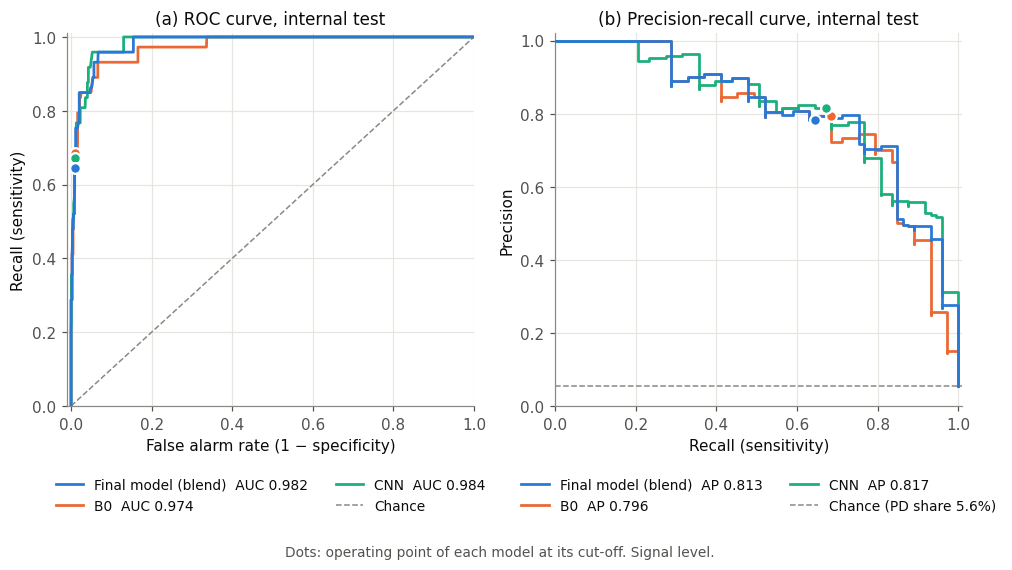

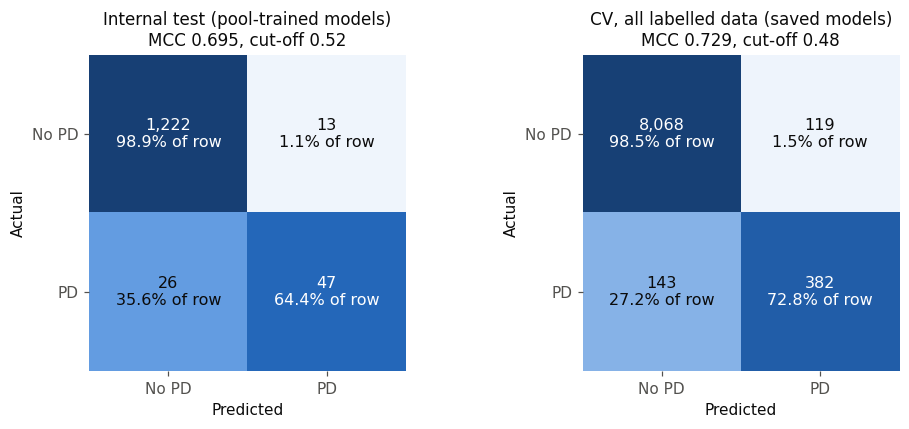

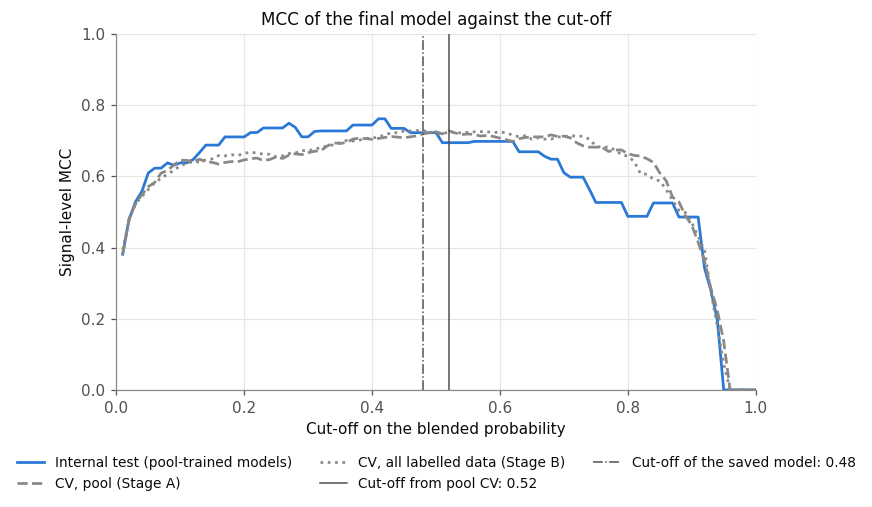

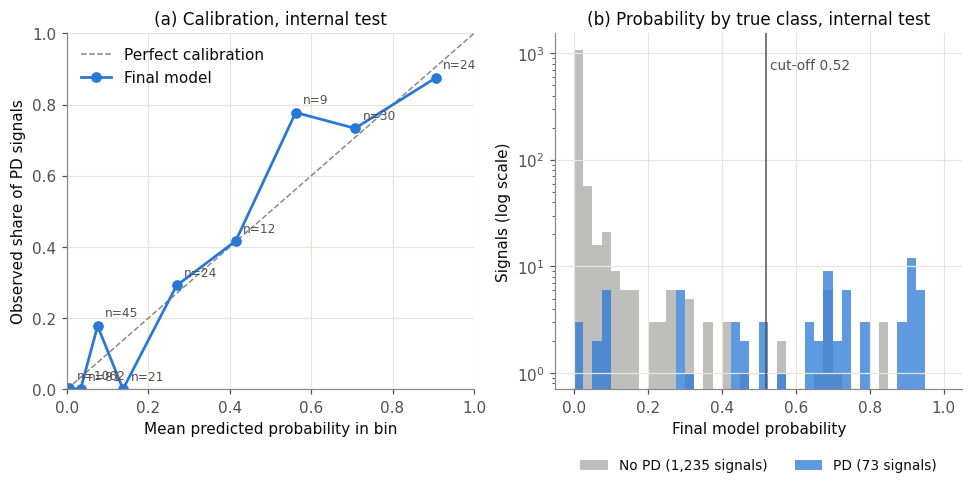

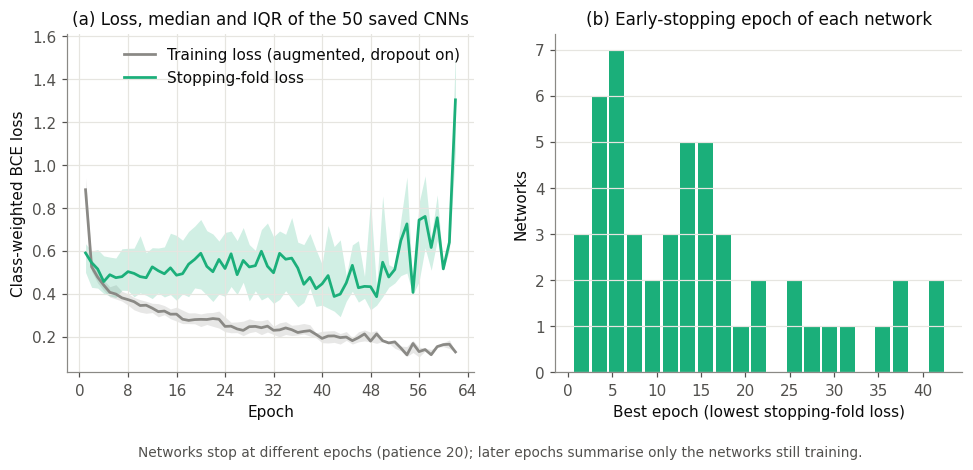

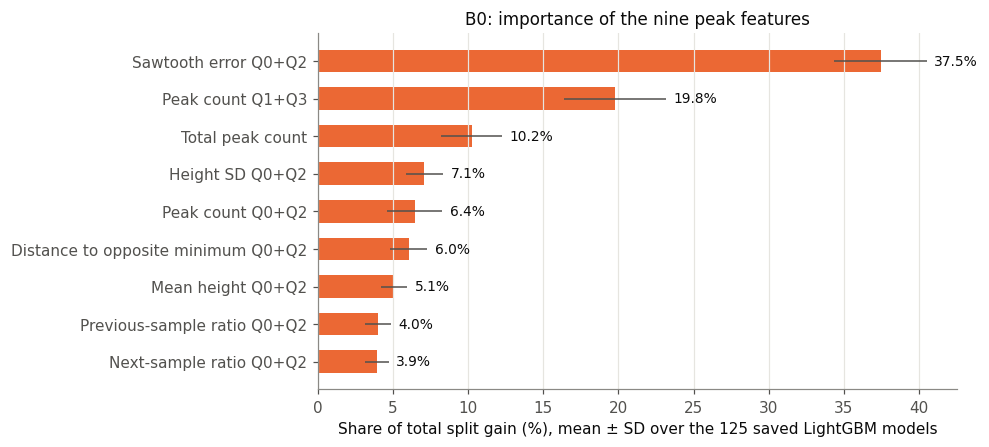

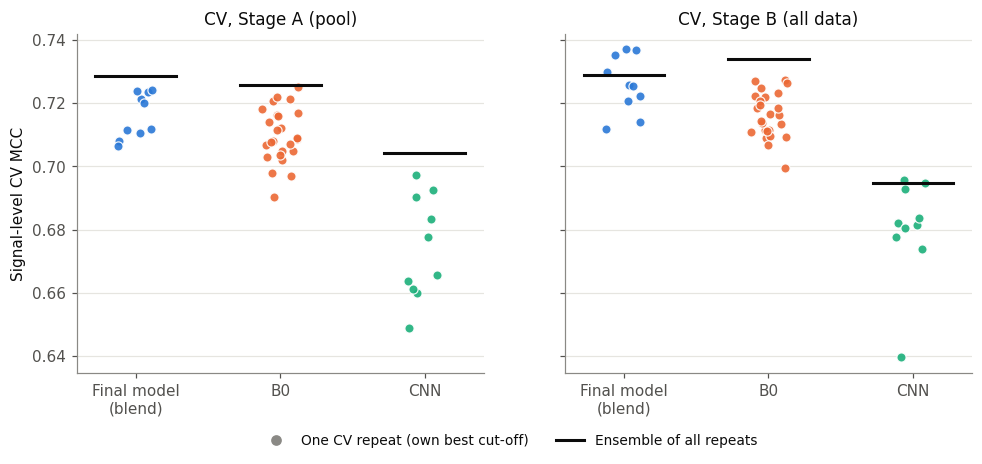

In [16]:
def save(fig, name):
    fig.savefig(f'{FIG_DIR}/{name}.png'); plt.show(); plt.close(fig)

ORDER = ['Final model (blend)', 'B0', 'CNN']
if internal is not None:
    PRIM, P_IDS, P_SIG = 'internal test', test_ids, test_sig
    P = {NAMES[k]: (p_test[k], p_test_cal[k], cutA[k]) for k in ['Blend', 'B0', 'CNN']}
else:
    PRIM, P_IDS, P_SIG = 'CV, all labelled data', ids_all, all_sig
    P = {n: (oofB[n][0], oofB[n][1], cutB[n]) for n in ORDER}
ys_p = P_SIG['target'].values

# Figure 1: ROC and precision-recall curves
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.4))
for name in ORDER:
    p, _, c = P[name]; ps = to_signal(p, P_IDS, P_SIG); m = metrics(p, c, P_IDS, P_SIG)
    z = 3 if name == ORDER[0] else 2
    fpr, tpr, _ = roc_curve(ys_p, ps)
    ax[0].plot(fpr, tpr, color=COL[name], zorder=z, label=f'{name}  AUC {m["ROC_AUC"]:.3f}')
    ax[0].plot(m['False_alarm_rate'], m['Recall'], 'o', ms=7, color=COL[name], mec='white', mew=1.5, zorder=z + 2)
    pr, rc, _ = precision_recall_curve(ys_p, ps)
    ax[1].plot(rc, pr, color=COL[name], zorder=z, drawstyle='steps-post', label=f'{name}  AP {m["PR_AUC"]:.3f}')
    ax[1].plot(m['Recall'], m['Precision'], 'o', ms=7, color=COL[name], mec='white', mew=1.5, zorder=z + 2)
ax[0].plot([0, 1], [0, 1], ls='--', lw=1, color=GREY, label='Chance')
ax[1].axhline(ys_p.mean(), ls='--', lw=1, color=GREY, label=f'Chance (PD share {ys_p.mean():.1%})')
ax[0].set(xlabel='False alarm rate (1 − specificity)', ylabel='Recall (sensitivity)', xlim=(-0.01, 1), ylim=(0, 1.01),
          title=f'(a) ROC curve, {PRIM}')
ax[1].set(xlabel='Recall (sensitivity)', ylabel='Precision', xlim=(0, 1.01), ylim=(0, 1.02), title=f'(b) Precision-recall curve, {PRIM}')
for a in ax:
    a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=9)
fig.text(0.5, -0.2, 'Dots: operating point of each model at its cut-off. Signal level.', ha='center', color=INK2, fontsize=9)
save(fig, 'fig1_roc_pr_curves')

# Figure 2: confusion matrices of the final model
CMAP = LinearSegmentedColormap.from_list('seq_blue', ['#f3f7fd', '#2a78d6', '#173f73'])
panels = ([('Internal test (pool-trained models)', P['Final model (blend)'][0], cutA['Blend'], test_ids, test_sig)] if internal is not None else [])
panels.append(('CV, all labelled data (saved models)', blend_oofB, CUTOFF, ids_all, all_sig))
fig, ax = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 4.0), squeeze=False)
for a, (title, p, c, i, s) in zip(ax[0], panels):
    m = metrics(p, c, i, s)
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]]); rowp = cm / cm.sum(axis=1, keepdims=True)
    a.imshow(rowp, cmap=CMAP, vmin=0, vmax=1)
    for r_ in range(2):
        for c_ in range(2):
            a.text(c_, r_, f'{cm[r_, c_]:,}\n{rowp[r_, c_]:.1%} of row', ha='center', va='center', fontsize=10.5,
                   color='white' if rowp[r_, c_] > 0.5 else INK)
    a.set_xticks([0, 1], ['No PD', 'PD']); a.set_yticks([0, 1], ['No PD', 'PD'])
    a.set(xlabel='Predicted', ylabel='Actual', title=f'{title}\nMCC {m["MCC"]:.3f}, cut-off {c}')
    a.grid(False)
    for sp in a.spines.values():
        sp.set_visible(False)
fig.tight_layout()
save(fig, 'fig2_confusion_matrices')

# Figure 3: MCC against the cut-off (final model)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
curves = [('CV, pool (Stage A)', modelsA['Blend'][0], pool_ids, pool_sig, dict(color=GREY, ls='--')),
          ('CV, all labelled data (Stage B)', blend_oofB, ids_all, all_sig, dict(color=GREY, ls=':'))]
if internal is not None:
    curves.insert(0, ('Internal test (pool-trained models)', p_test['Blend'], test_ids, test_sig, dict(color=COL['Final model (blend)'])))
for label, p, i, s, st in curves:
    ps, ys_ = to_signal(p, i, s), s['target'].values
    ax.plot(THRESHOLDS, [matthews_corrcoef(ys_, ps > t) for t in THRESHOLDS], label=label, **st)
for c, txt, ls in [(cutA['Blend'], 'Cut-off from pool CV', '-'), (CUTOFF, 'Cut-off of the saved model', '-.')]:
    ax.axvline(c, color=INK2, lw=1, ls=ls, label=f'{txt}: {c}')
ax.set(xlabel='Cut-off on the blended probability', ylabel='Signal-level MCC', xlim=(0, 1), ylim=(0, 1),
       title='MCC of the final model against the cut-off')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
save(fig, 'fig3_mcc_vs_cutoff')

# Figure 4: calibration and score distribution (final model)
p, p_cal, c = P['Final model (blend)']
ps = to_signal(p_cal, P_IDS, P_SIG)
edges = np.array([0, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 1.0001])
b = np.digitize(ps, edges) - 1
cal_tab = pd.DataFrame({'bin': b, 'p': ps, 'y': ys_p}).groupby('bin').agg(mean_p=('p', 'mean'), observed=('y', 'mean'), n=('y', 'size')).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax[0].plot([0, 1], [0, 1], ls='--', lw=1, color=GREY, label='Perfect calibration')
ax[0].plot(cal_tab['mean_p'], cal_tab['observed'], '-o', ms=6, color=COL['Final model (blend)'], label='Final model')
for _, rw in cal_tab.iterrows():
    ax[0].annotate(f'n={int(rw.n)}', (rw.mean_p, rw.observed), textcoords='offset points', xytext=(5, 6), fontsize=8, color=INK2)
ax[0].set(xlabel='Mean predicted probability in bin', ylabel='Observed share of PD signals', xlim=(0, 1), ylim=(0, 1),
          title=f'(a) Calibration, {PRIM}')
ax[0].legend(loc='upper left')
bins = np.linspace(0, 1, 41)
ax[1].hist(ps[ys_p == 0], bins, color=GREY, alpha=0.55, label=f'No PD ({int((ys_p == 0).sum()):,} signals)')
ax[1].hist(ps[ys_p == 1], bins, color=COL['Final model (blend)'], alpha=0.75, label=f'PD ({int((ys_p == 1).sum()):,} signals)')
ax[1].axvline(c, color=INK2, lw=1); ax[1].text(c + 0.01, 0.9, f'cut-off {c}', transform=ax[1].get_xaxis_transform(), color=INK2, fontsize=9)
ax[1].set_yscale('log')
ax[1].set(xlabel='Final model probability', ylabel='Signals (log scale)', title=f'(b) Probability by true class, {PRIM}')
ax[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=9)
save(fig, 'fig4_calibration_and_scores')

# Figure 5: CNN learning curves (saved Stage B networks)
h = pd.DataFrame(cnnB['history'])
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0))
for col, color, label in [('train_loss', GREY, 'Training loss (augmented, dropout on)'), ('stopping_loss', COL['CNN'], 'Stopping-fold loss')]:
    q = h.groupby('epoch')[col].quantile([0.25, 0.5, 0.75]).unstack()
    ax[0].plot(q.index, q[0.5], color=color, label=label)
    ax[0].fill_between(q.index, q[0.25], q[0.75], color=color, alpha=0.2, lw=0)
ax[0].set(xlabel='Epoch', ylabel='Class-weighted BCE loss', title=f'(a) Loss, median and IQR of the {len(cnnB["epochs"])} saved CNNs')
ax[0].legend(loc='upper right')
ax[1].hist(cnnB['epochs'], bins=np.arange(0.5, max(cnnB['epochs']) + 1.5, max(1, int(np.ceil(max(cnnB['epochs']) / 30)))),
           color=COL['CNN'], rwidth=0.85)
ax[1].set(xlabel='Best epoch (lowest stopping-fold loss)', ylabel='Networks', title='(b) Early-stopping epoch of each network')
ax[1].grid(axis='x', visible=False)
for a in ax:
    a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
fig.text(0.5, -0.08, 'Networks stop at different epochs (patience 20); later epochs summarise only the networks still training.',
         ha='center', color=INK2, fontsize=9)
save(fig, 'fig5_cnn_learning_curves')

# Figure 6: B0 feature importance
fi = feat_imp.iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(fi['Label'], fi['Gain share, mean (%)'], xerr=fi['Gain share, SD (%)'], color=COL['B0'], height=0.6,
        error_kw=dict(ecolor=INK2, lw=1, capsize=0))
for yv, v in enumerate(fi['Gain share, mean (%)']):
    ax.text(v + fi['Gain share, SD (%)'].iloc[yv] + 0.5, yv, f'{v:.1f}%', va='center', fontsize=9, color=INK)
ax.set(xlabel=f'Share of total split gain (%), mean ± SD over the {len(det.b0)} saved LightGBM models',
       title='B0: importance of the nine peak features')
ax.grid(axis='y', visible=False)
save(fig, 'fig6_b0_feature_importance')

# Figure 7: stability across CV repeats
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.0), sharey=True)
for a, stage in zip(ax, ['Stage A (pool)', 'Stage B (all data)']):
    d = per_repeat[per_repeat['Stage'] == stage]
    for j, name in enumerate(ORDER):
        v = d[d['Model'] == name]['Signal MCC'].values
        a.plot(j + np.random.default_rng(j).uniform(-0.13, 0.13, len(v)), v, 'o', ms=6, color=COL[name], mec='white', mew=0.8, alpha=0.9)
        a.plot([j - 0.28, j + 0.28], [ens[(stage, name)]] * 2, color=INK, lw=2)
    a.set_xticks(range(3), ['Final model\n(blend)', 'B0', 'CNN']); a.grid(axis='x', visible=False)
    a.set_title(f'CV, {stage}')
ax[0].set_ylabel('Signal-level CV MCC')
lo_, hi_ = ax[0].get_ylim(); mid_ = (lo_ + hi_) / 2
if hi_ - lo_ < 0.05:
    ax[0].set_ylim(mid_ - 0.025, mid_ + 0.025)
fig.legend(handles=[plt.Line2D([], [], marker='o', ls='', color=GREY, label='One CV repeat (own best cut-off)'),
                    plt.Line2D([], [], color=INK, lw=2, label='Ensemble of all repeats')],
           loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=2, fontsize=9)
save(fig, 'fig7_cv_repeat_stability')

## C5. Export the tables and the summary

`report/` contains every table as CSV, `metrics_summary.json` (all numbers in one file) and `evaluation_summary.md` (the main tables in Markdown, ready to paste into the report, with the figure captions and a short glossary of the metrics).

In [17]:
TIMES['Notebook run time up to the export (min)'] = round((time.time() - T_START) / 60, 1)
hist_all = pd.concat([pd.DataFrame(cnnA['history']).assign(stage='A (pool)'), pd.DataFrame(cnnB['history']).assign(stage='B (all data)')])
tables = {'metrics_signal_level': tab_signal, 'metrics_measurement_level': tab_meas, 'cv_per_repeat': per_repeat,
          'cv_per_repeat_summary': rep_summary, 'stage_A_reproduction_check': stageA, 'b0_feature_importance': feat_imp,
          'cnn_training_history': hist_all, 'model_facts': model_facts}
if internal is not None:
    tables.update(internal_test_bootstrap_ci=internal_ci_table, internal_test_paired_comparison=internal_paired)
for name, df in tables.items():
    df.to_csv(f'{REPORT_DIR}/{name}.csv', index=False)

def rec(df):
    return json.loads(df.to_json(orient='records'))
summary = {'generated_by': '15_final_model_training.ipynb', 'date': time.strftime('%Y-%m-%d %H:%M'), 'quick_test': QUICK_TEST,
           'final_model': {'blend_weight_cnn': W_FINAL, 'cutoff_saved_model': CUTOFF, 'cutoff_pool_models': cutA['Blend'],
                           'calibration_saved_model': calB},
           'internal_test': None if internal is None else {'signal_level': rec(internal), 'measurement_level': rec(internal_meas),
                                                           'bootstrap_ci_final_model': rec(internal_ci_table),
                                                           'paired_comparison': rec(internal_paired), 'n_bootstrap': N_BOOT},
           'metrics_signal_level': rec(tab_signal), 'metrics_measurement_level': rec(tab_meas),
           'cv_per_repeat_summary': rec(rep_summary), 'stage_A_reproduction_check': rec(stageA), 'blend_weight_chosen_on_pool': W_A,
           'b0_feature_importance': rec(feat_imp.drop(columns='Description')), 'model_facts': facts,
           'kaggle_hidden_test': {'test7_blend_pool_models': {'private': 0.70263, 'public': 0.68932},
                                  'submission_final_model_all_data.csv': {'private': None, 'public': None,
                                                                          'predicted_pd_signals': int(sub['target'].sum())}}}
with open(f'{REPORT_DIR}/metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

def md_table(df, digits=3):
    def fmt(v):
        if isinstance(v, (float, np.floating)):
            return '—' if np.isnan(v) else f'{v:.{digits}f}'
        return f'{v:,}' if isinstance(v, (int, np.integer)) else str(v)
    lines = ['| ' + ' | '.join(map(str, df.columns)) + ' |', '|' + '---|' * df.shape[1]]
    return '\n'.join(lines + ['| ' + ' | '.join(fmt(v) for v in row) + ' |' for row in df.itertuples(index=False)])

A_COLS = ['Model', 'Cut-off', 'MCC', 'F1', 'Recall', 'Precision', 'Specificity', 'Balanced_accuracy', 'ROC_AUC', 'PR_AUC', 'Brier']
B_COLS = ['Model', 'TP', 'FN', 'FP', 'TN', 'NPV', 'False_alarm_rate', 'Accuracy']
out = [f'# Final model — performance summary', '',
       f'Generated by `15_final_model_training.ipynb` on {summary["date"]}' + (' — **QUICK TEST: numbers are not valid**' if QUICK_TEST else '') + '.',
       f'Final model: calibrated blend, CNN weight {W_FINAL}, B0 weight {1 - W_FINAL}. Cut-off {cutA["Blend"]} for the pool-trained models '
       f'(internal test), {CUTOFF} for the saved all-data models. Signal level unless stated.', '']
if internal is not None:
    out += ['## 1. Internal test — final model with 95% bootstrap confidence intervals', '',
            f'One-time evaluation of the pool-trained models on {len(test_sig):,} signals ({int(test_sig["target"].sum())} PD) '
            f'from {len(test_ids)} measurements; {N_BOOT:,} bootstrap resamples of measurements.', '',
            md_table(internal_ci_table), '', '### Paired comparison with B0 and the CNN (same resamples)', '', md_table(internal_paired), '']
sec = 2
for e in tab_signal['Evaluation'].unique():
    d = tab_signal[tab_signal['Evaluation'] == e]
    out += [f'## {sec}. {e} — all models', '', md_table(d[A_COLS]), '', md_table(d[B_COLS]), '']
    sec += 1
out += [f'## {sec}. Measurement level (a recording is PD if any phase is PD)', '',
        md_table(tab_meas[['Evaluation'] + A_COLS[:-1]]), '',
        f'## {sec + 1}. Stability across CV repeats', '', md_table(rep_summary, 4), '',
        f'## {sec + 2}. Model size, training and prediction time', '', md_table(model_facts), '',
        f'## {sec + 3}. B0 feature importance', '', md_table(feat_imp[['Label', 'Feature', 'Gain share, mean (%)', 'Gain share, SD (%)']], 2), '',
        f'## {sec + 4}. Kaggle hidden test (fill in after submitting)', '',
        '| Model | Training data | Private | Public |', '|---|---|---|---|',
        '| Test 7 blend (same recipe) | Pool | 0.70263 | 0.68932 |',
        f'| Final model, `submission_final_model_all_data.csv` ({int(sub["target"].sum())} predicted PD signals) | All labelled data | [RECORD] | [RECORD] |', '',
        f'## {sec + 5}. Figures', '',
        f'1. `fig1_roc_pr_curves.png` — ROC and precision-recall curves of the three models ({PRIM}); dots mark each model\'s operating point at its cut-off.',
        '2. `fig2_confusion_matrices.png` — confusion matrices of the final model' + (' (internal test and all-data CV).' if internal is not None else ' (all-data CV).'),
        '3. `fig3_mcc_vs_cutoff.png` — MCC of the final model against the cut-off: how sensitive the result is to the chosen cut-off.',
        f'4. `fig4_calibration_and_scores.png` — calibration (predicted probability vs observed PD share) and the probability distribution of PD and non-PD signals ({PRIM}).',
        '5. `fig5_cnn_learning_curves.png` — training and stopping-fold loss of the saved CNNs and their early-stopping epochs.',
        '6. `fig6_b0_feature_importance.png` — share of the split gain of each of B0\'s nine peak features.',
        '7. `fig7_cv_repeat_stability.png` — per-repeat CV MCC of each model and the ensemble value.', '',
        f'## {sec + 6}. Metric glossary', '',
        '- **MCC (Matthews correlation coefficient):** correlation between predicted and true labels, from −1 to +1; 0 = no better than guessing. Uses all four confusion counts, so it stays honest when PD is rare. The competition metric.',
        '- **Recall (sensitivity):** share of real PD signals that are detected. **Precision:** share of PD alarms that are real PD.',
        '- **Specificity:** share of non-PD signals correctly left alone; **false alarm rate** = 1 − specificity. **NPV:** share of "no PD" decisions that are correct.',
        '- **F1:** harmonic mean of precision and recall. **Balanced accuracy:** mean of recall and specificity.',
        '- **ROC AUC:** chance that a random PD signal gets a higher score than a random non-PD signal (0.5 = guessing, 1 = perfect); independent of the cut-off.',
        '- **PR AUC (average precision):** area under the precision-recall curve; guessing scores the PD share (about 6%), so it is more informative than ROC AUC when PD is rare.',
        '- **Brier score:** mean squared difference between the probability and the true label (0 = perfect); measures how trustworthy the probabilities are.',
        '- **Accuracy:** misleading for this data: predicting "no PD" for every signal already scores about 94%.']
with open(f'{REPORT_DIR}/evaluation_summary.md', 'w') as f:
    f.write('\n'.join(out) + '\n')
print('report/:')
for root_, _, files in os.walk(REPORT_DIR):
    for fn in sorted(files):
        print(f'  {os.path.relpath(os.path.join(root_, fn), REPORT_DIR):45s} {os.path.getsize(os.path.join(root_, fn)) / 1e3:9.1f} kB')

report/:
  b0_feature_importance.csv                           1.2 kB
  cnn_training_history.csv                          199.5 kB
  cv_per_repeat.csv                                   3.7 kB
  cv_per_repeat_summary.csv                           0.6 kB
  evaluation_summary.md                               9.9 kB
  internal_test_bootstrap_ci.csv                      0.3 kB
  internal_test_paired_comparison.csv                 0.6 kB
  internal_test_predictions.csv                      99.0 kB
  metrics_measurement_level.csv                       1.7 kB
  metrics_signal_level.csv                            1.7 kB
  metrics_summary.json                               23.2 kB
  model_facts.csv                                     0.6 kB
  stage_A_reproduction_check.csv                      0.2 kB
  figures/fig1_roc_pr_curves.png                    135.5 kB
  figures/fig2_confusion_matrices.png                91.5 kB
  figures/fig3_mcc_vs_cutoff.png                    120.0 kB
  figures/fig4_

## Package the final model and the report outputs

In [18]:
shutil.rmtree(f'{MODEL_DIR}/__pycache__', ignore_errors=True)
shutil.make_archive(f'{OUT_DIR}/final_model', 'zip', MODEL_DIR)
shutil.make_archive(f'{OUT_DIR}/report_outputs', 'zip', REPORT_DIR)
for fn in ['final_model.zip', 'report_outputs.zip', 'submission_final_model_all_data.csv']:
    print(f'{fn:40s} {os.path.getsize(f"{OUT_DIR}/{fn}") / 1e6:7.1f} MB')
print(f'Total run time: {(time.time() - T_START) / 60:.1f} min')

final_model.zip                            102.7 MB
report_outputs.zip                           0.9 MB
submission_final_model_all_data.csv          0.2 MB
Total run time: 14.9 min
